# MetroBus Analytics - Álvaro Medina

## 01. Introducción

Una vez leído el enunciado, antes de entrar en materia y empezar con la parte técnica, surgen diferentes preguntas que se tratarán de responder con este proyecto junto con las que puedan ir surgiendo a lo largo del mismo:

**¿Qué quiere/necesita la empresa?**

A nivel **operativo** deberemos tratar de responder:

- ¿Qué línea(s) funciona(n) peor/mejor?
- ¿Qué línea(s) sufre(n) más retraso(s)?
- ¿Qué horario es el más problemático? Centrándonos en las incidencias que no tengan que ver con los retrasos

En cuanto a la **demanda** surgen preguntas como:

- ¿Qué línea(s) tiene(n) más/menos ocupación?
- ¿Cuándo viaja más gente?
- ¿Qué tarifa es la más usada?

Hablando de **sostenibilidad** se plantean:

- ¿Qué vehículos/marcas/motorizaciones fallan más/menos?
- ¿Qué coste suponen las averías/incidencias en la flota?

Sobre el **mantenimiento** y la **posible electrificación** de la flota:

- ¿Qué beneficios aportan los eléctricos/híbridos?
- ¿Realmente tienen menos consumo? ¿Y/o menos incidencias?

También podríamos hablar sobre los **conductores**:

- ¿Hay diferencia entre ellos? Según el turno, cochera/depot, línea, etc...
- En caso afirmativo ¿Qué provoca esa diferencia?

## 02. Carga de datos

Una vez planteados los preámbulos, ya si podemos empezar con el proyecto en sí. Para objetivo del análisis, descripción general de los datasets, etc... consultar `00-enunciado.ipynb` en este mismo proyecto

In [1]:
# Importamos todas las librerías que vamos a necesitar a lo largo del proyecto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargamos todos los datasets del proyecto

fact_viajes = pd.read_csv('data/fact_viajes.csv')
fact_incidencias = pd.read_csv('data/fact_incidencias.csv')
fact_mantenimiento = pd.read_csv('data/fact_mantenimiento.csv')
dim_linea = pd.read_csv('data/dim_linea.csv')
dim_vehiculo = pd.read_csv('data/dim_vehiculo.csv')
dim_conductor = pd.read_csv('data/dim_conductor.csv')
dim_parada = pd.read_csv('data/dim_parada.csv')
dim_tarifa = pd.read_csv('data/dim_tarifa.csv')
dim_depot = pd.read_csv('data/dim_depot.csv')

## 03. Inspección inicial

### 03.1. Tabla (de hechos) viajes `fact_viajes`

In [3]:
# Tamaño de la tabla (Filas, Columnas)
fact_viajes.shape

(50000, 24)

In [4]:
# Nombre de las columnas
fact_viajes.columns

Index(['viaje_id', 'linea_id', 'vehiculo_id', 'conductor_id',
       'parada_origen_id', 'parada_destino_id', 'fecha', 'anno', 'mes',
       'dia_semana', 'es_festivo', 'franja_horaria', 'hora_salida_prog',
       'hora_salida_real', 'hora_llegada_real', 'retraso_salida_min',
       'duracion_real_min', 'pasajeros_subidos', 'ocupacion_pct',
       'km_programados', 'km_recorridos', 'viaje_completado', 'consumo',
       'tarifa_predominante_id'],
      dtype='object')

In [5]:
# Usamos esta opción para mostrar todas las columnas del dataframe
pd.set_option('display.max_columns', None)

# Muestra de las primeras filas de la tabla
fact_viajes.head()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
0,1,4,2,2,17,116,2023-08-14,2023,8,Monday,False,Tarde punta,17:50,18:09,19:22,19,73,78.0,0.609,14.1,14.1,True,4.69,4
1,2,4,3,3,5,48,2024-05-20,2024,5,Monday,False,Manana punta,07:10,07:23,08:30,13,67,115.0,0.885,14.1,14.1,True,5.86,2
2,3,5,4,4,33,110,2023-08-15,2023,8,Tuesday,False,Valle manana,12:30,12:30,13:05,0,35,47.0,0.362,7.3,7.3,True,3.15,3
3,4,2,5,5,37,116,2022-03-23,2022,3,Wednesday,False,Tarde punta,20:50,20:50,21:36,0,46,111.0,0.888,11.2,11.2,True,3.50,9
4,5,5,6,6,12,115,2022-03-24,2022,3,Thursday,False,Tarde punta,18:10,18:18,18:50,8,32,75.0,0.405,7.3,7.3,True,3.13,3


In [6]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
fact_viajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   viaje_id                50000 non-null  int64  
 1   linea_id                50000 non-null  int64  
 2   vehiculo_id             50000 non-null  int64  
 3   conductor_id            50000 non-null  int64  
 4   parada_origen_id        50000 non-null  int64  
 5   parada_destino_id       50000 non-null  int64  
 6   fecha                   50000 non-null  object 
 7   anno                    50000 non-null  int64  
 8   mes                     50000 non-null  int64  
 9   dia_semana              50000 non-null  object 
 10  es_festivo              50000 non-null  bool   
 11  franja_horaria          50000 non-null  object 
 12  hora_salida_prog        50000 non-null  object 
 13  hora_salida_real        50000 non-null  object 
 14  hora_llegada_real       50000 non-null

In [7]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
fact_viajes.describe()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,anno,mes,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,consumo,tarifa_predominante_id
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,49960.000000,50000.000000,50000.000000,50000.000000,48935.000000,50000.000000
mean,25000.500000,5.502600,21.496000,14.498800,20.547780,80.454760,2023.000380,6.518820,3.89218,62.600340,61.283907,0.455362,14.014620,13.910457,7.695104,3.606020
std,14433.901067,2.865665,12.120814,8.077258,11.562176,23.126044,0.816917,3.448467,6.76309,23.849155,36.847517,0.264251,4.949592,4.999930,6.221862,2.160808
min,1.000000,1.000000,1.000000,1.000000,1.000000,41.000000,2022.000000,1.000000,-99.00000,25.000000,1.000000,0.005000,7.300000,2.200000,0.550000,1.000000
25%,12500.750000,3.000000,11.000000,7.000000,11.000000,60.000000,2022.000000,4.000000,1.00000,44.000000,30.000000,0.227000,9.700000,9.700000,3.600000,2.000000
50%,25000.500000,6.000000,21.000000,14.000000,21.000000,80.500000,2023.000000,7.000000,2.00000,58.000000,56.000000,0.422000,12.600000,12.600000,5.340000,3.000000
75%,37500.250000,8.000000,32.000000,21.000000,31.000000,100.000000,2024.000000,10.000000,5.00000,78.000000,91.000000,0.688000,18.400000,18.400000,9.080000,5.000000
max,50000.000000,10.000000,42.000000,28.000000,40.000000,120.000000,2024.000000,12.000000,50.00000,129.000000,184.000000,0.995000,23.500000,23.500000,32.860000,9.000000


In [8]:
# Comprobamos también los datos de la columnas categóricas, para validar si los datos tienen sentido

print("Valores días de la semana:")
print(fact_viajes['dia_semana'].value_counts())
print("Valores franja horaria:")
print(fact_viajes['franja_horaria'].value_counts())
print("Valores viaje_completado:")
print(fact_viajes['viaje_completado'].value_counts())
print("Valores es_festivo:")
print(fact_viajes['es_festivo'].value_counts())


Valores días de la semana:
dia_semana
Thursday     7259
Tuesday      7250
Monday       7189
Wednesday    7109
Sunday       7066
Saturday     7057
Friday       7040
FRIDAY          6
THURSDAY        6
SUNDAY          5
TUESDAY         5
WEDNESDAY       4
SATURDAY        3
MONDAY          1
Name: count, dtype: int64
Valores franja horaria:
franja_horaria
Valle manana    13667
Tarde punta     11213
Manana punta     8958
Tarde            7266
Noche            6894
Madrugada        2002
Name: count, dtype: int64
Valores viaje_completado:
viaje_completado
True     49027
False      973
Name: count, dtype: int64
Valores es_festivo:
es_festivo
False    35869
True     14131
Name: count, dtype: int64


**Inspección inicial de `fact_viajes`**

La tabla contiene 50.000 registros y 24 columnas.

Se observan identificadores (id) de viaje, vehículo, línea, paradas, tarifa predominante, así como métricas operativas relacionadas con tiempos de recorrido, ocupación, consumo, retrasos, y sobre las circunstancias del servicio, si corresponde a un festivo, si se ha completado, etc...

En una revisión preliminar, las variables parecen haberse importado correctamente. Las columnas referidas a fecha y hora (salida y llegada tanto programada como real) tienen formato string (object), por lo que habrá que transformarlas al correcto (DateTime). En las variables numéricas llaman la atención un valor mínimo de -99 en retraso_salida_min, un valor máximo de 184 pasajeros subidos, se debe revisar `dim_vehiculo` para comprobar si el número de pasajeros subidos es coherente con la capacidad de los vehículos, se entiende por los valores arrojados en ocupacion_pct están almacenados como proporción (valorar si hay que transformarlos a %). El tipo de valor de pasajeros_subidos es tipo float por la presencia de valores nulos De las variables categóricas se ha comprobado la coherencia de sus valores: viaje_completado y es_festivo presentan los valores esperados (True y False), franja_horaria contiene categorías operativas coherentes (6 diferentes) con la planificación del servicio. Sin embargo, en la variable dia_semana se detecta una inconsistencia de formato, ya que algunos registros aparecen en mayúsculas completas mientras que otros utilizan capitalización estándar (Ambos son lo mismo pero en posteriores análisis automáticos, serían interpretadas como distintas).

Se observan también valores nulos en las variables pasajeros_subidos (40) y consumo (1.065), que analizaremos más adelante, al hablar de la calidad de los datos.

### 03.2. Tabla (de hechos) incidencias `fact_incidencias`

In [9]:
# Tamaño de la tabla (Filas, Columnas)
fact_incidencias.shape

(4000, 16)

In [10]:
# Nombre de las columnas
fact_incidencias.columns

Index(['incidencia_id', 'viaje_id', 'vehiculo_id', 'conductor_id', 'linea_id',
       'fecha', 'anno', 'mes', 'hora_incidencia', 'tipo_incidencia',
       'categoria', 'severidad', 'requiere_retirada',
       'duracion_resolucion_min', 'vehiculo_sustituto', 'coste_estimado_eur'],
      dtype='object')

In [11]:
# Muestra de las primeras filas de la tabla
fact_incidencias.head()

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
0,1,33554,39,11,4,2022-06-01,2022,6,19:11,Huelga parcial,Operacional,Alta,True,60,False,0.00
1,2,9428,21,21,6,2023-02-16,2023,2,20:42,Fallo electrico,Vehiculo,Alta,True,62,False,575.51
2,3,200,33,5,8,2022-01-20,2022,1,06:21,Accidente leve,Seguridad,Alta,True,29,True,3318.00
3,4,12448,17,17,10,2023-01-16,2023,1,02:30,Vandalismo,Seguridad,Media,False,16,False,651.99
4,5,39490,11,11,6,2023-01-08,2023,1,14:51,Retencion trafico,Externo,Baja,False,14,False,49.88


In [12]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
fact_incidencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   incidencia_id            4000 non-null   int64  
 1   viaje_id                 4000 non-null   int64  
 2   vehiculo_id              4000 non-null   int64  
 3   conductor_id             4000 non-null   int64  
 4   linea_id                 4000 non-null   int64  
 5   fecha                    4000 non-null   object 
 6   anno                     4000 non-null   int64  
 7   mes                      4000 non-null   int64  
 8   hora_incidencia          4000 non-null   object 
 9   tipo_incidencia          4000 non-null   object 
 10  categoria                4000 non-null   object 
 11  severidad                4000 non-null   object 
 12  requiere_retirada        4000 non-null   bool   
 13  duracion_resolucion_min  4000 non-null   int64  
 14  vehiculo_sustituto      

In [13]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
fact_incidencias.describe()

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,anno,mes,duracion_resolucion_min,coste_estimado_eur
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000
mean,2000.500000,24813.572250,21.342250,14.622250,5.562250,2023.028000,6.546250,28.61075,1198.774348
std,1154.844867,14311.117206,12.140674,8.111967,2.850378,0.812331,3.478561,34.06862,2575.401240
min,1.000000,5.000000,1.000000,1.000000,1.000000,2022.000000,1.000000,5.00000,0.000000
25%,1000.750000,12580.500000,11.000000,8.000000,3.000000,2022.000000,3.000000,6.00000,0.000000
50%,2000.500000,24807.500000,21.000000,15.000000,6.000000,2023.000000,7.000000,17.00000,183.910000
75%,3000.250000,36905.250000,32.000000,22.000000,8.000000,2024.000000,10.000000,37.00000,1204.757500
max,4000.000000,49989.000000,42.000000,28.000000,10.000000,2024.000000,12.000000,333.00000,14985.580000


In [14]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido

print("Valores tipo de incidencia:")
print(fact_incidencias['tipo_incidencia'].value_counts())
print("Valores Categoría de incidencia:")
print(fact_incidencias['categoria'].value_counts())
print("Valores severidad:")
print(fact_incidencias['severidad'].value_counts())
print("Valores requiere_retirada:")
print(fact_incidencias['requiere_retirada'].value_counts())
print("Valores Vehículo sustituto:")
print(fact_incidencias['vehiculo_sustituto'].value_counts())

Valores tipo de incidencia:
tipo_incidencia
Condiciones meteo      382
Averia mecanica        347
Obras calzada          340
Huelga parcial         339
Pinchazo               335
Fallo electrico        332
Accidente leve         332
Vandalismo             330
Accidente grave        328
Retencion trafico      312
Fallo climatizacion    312
Pasajero enfermo       311
Name: count, dtype: int64
Valores Categoría de incidencia:
categoria
Vehiculo       1326
Externo        1034
Seguridad       990
Operacional     339
Servicio        311
Name: count, dtype: int64
Valores severidad:
severidad
Media      1698
Alta       1350
Baja        624
Critica     328
Name: count, dtype: int64
Valores requiere_retirada:
requiere_retirada
True     2013
False    1987
Name: count, dtype: int64
Valores Vehículo sustituto:
vehiculo_sustituto
False    2574
True     1426
Name: count, dtype: int64


**Inspección inicial de `fact_incidencias`**

La tabla contiene 4.000 registros y 16 columnas.

Se observan identificadores (id) de incidencia, viaje, vehículo, conductor, línea, así como métricas relacionadas con las incidencias: Categoría, severidad, etc... y circunstancias de la misma: si requiere retirada, vehículo de sustitución, el coste servicio, si corresponde a un festivo, si se ha completado, etc...

En una revisión preliminar, las variables parecen haberse importado correctamente. Las columnas referidas a fecha y hora vuelven a tener formato string (object), por lo que habrá que transformarlas al correcto (DateTime). En las variables numéricas se han detectado puntos que llaman la atención en comparación con el resto de guarismos, aunque no necesariamente tienen que ser errores, en duracion_resolucion_min un máximo de 333, y en coste_estimado_eur otro máximo de 14.985,85. Las variables categoricas arrojan valores coherentes con lo que se espera de ellas, y en este dataset no hay valores nulos.

### 03.3. Tabla (de hechos) mantenimiento `fact_mantenimiento`

In [15]:
# Tamaño de la tabla (Filas, Columnas)
fact_mantenimiento.shape

(876, 15)

In [16]:
# Nombre de las columnas
fact_mantenimiento.columns

Index(['mantenimiento_id', 'vehiculo_id', 'depot_id', 'fecha_entrada',
       'fecha_salida', 'anno', 'mes', 'tipo_mantenimiento', 'categoria',
       'es_correctivo', 'dias_fuera_servicio', 'km_en_revision', 'coste_eur',
       'proveedor', 'garantia_meses'],
      dtype='object')

In [17]:
# Muestra las primeras filas de la tabla
fact_mantenimiento.head()

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
0,1,1,1,2024-07-24,2024-07-25,2024,7,Cambio aceite,Preventivo,False,1,278454,218.70,TallerBus Norte,0
1,2,1,1,2023-02-08,2023-02-09,2023,2,Cambio neumaticos,Preventivo,False,1,240059,1068.93,TallerBus Norte,0
2,3,1,1,2024-10-28,2024-10-29,2024,10,Cambio neumaticos,Preventivo,False,1,493071,722.19,Taller Oficial Mercedes,0
3,4,1,1,2022-08-01,2022-08-03,2022,8,Reparacion clima,Correctivo,True,2,533556,579.93,FlotaService,6
4,5,1,1,2024-12-09,2024-12-10,2024,12,Revision bateria,Preventivo,False,1,307110,436.54,TallerBus Norte,0


In [18]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
fact_mantenimiento.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   mantenimiento_id     876 non-null    int64  
 1   vehiculo_id          876 non-null    int64  
 2   depot_id             876 non-null    int64  
 3   fecha_entrada        876 non-null    object 
 4   fecha_salida         876 non-null    object 
 5   anno                 876 non-null    int64  
 6   mes                  876 non-null    int64  
 7   tipo_mantenimiento   876 non-null    object 
 8   categoria            861 non-null    object 
 9   es_correctivo        876 non-null    bool   
 10  dias_fuera_servicio  876 non-null    int64  
 11  km_en_revision       876 non-null    int64  
 12  coste_eur            876 non-null    float64
 13  proveedor            876 non-null    object 
 14  garantia_meses       876 non-null    int64  
dtypes: bool(1), float64(1), int64(8), object

In [19]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
fact_mantenimiento.describe()

,mantenimiento_id,vehiculo_id,depot_id,anno,mes,dias_fuera_servicio,km_en_revision,coste_eur,garantia_meses
count,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000,876.000000
mean,438.500000,22.707763,1.850457,2023.252283,6.276256,1.898402,277372.776256,742.520879,2.075342
std,253.023714,12.839278,0.782238,0.882364,3.668109,1.963658,156043.953693,924.806659,3.876232
min,1.000000,1.000000,1.000000,2022.000000,1.000000,0.000000,10222.000000,-4083.030000,0.000000
25%,219.750000,12.000000,1.000000,2023.000000,3.000000,1.000000,143531.500000,237.712500,0.000000
50%,438.500000,22.000000,2.000000,2023.000000,6.000000,1.000000,266619.500000,455.085000,0.000000
75%,657.250000,33.000000,2.000000,2024.000000,9.000000,3.000000,415184.750000,922.100000,3.000000
max,876.000000,45.000000,3.000000,2025.000000,12.000000,10.000000,549625.000000,4987.720000,12.000000


In [20]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido

print("Valores tipo de mantenimiento:")
print(fact_mantenimiento['tipo_mantenimiento'].value_counts())
print("Valores Categoría de mantenimiento:")
print(fact_mantenimiento['categoria'].value_counts())
print("Valores es_correctivo:")
print(fact_mantenimiento['es_correctivo'].value_counts())
print("Valores de proveedor:")
print(fact_mantenimiento['proveedor'].value_counts())

Valores tipo de mantenimiento:
tipo_mantenimiento
Reparacion clima        102
Revision periodica       99
Revision bateria         94
ITV e Inspeccion         91
Cambio aceite            90
Sistema electrico        89
Carroceria y pintura     87
Cambio neumaticos        79
Reparacion motor         76
Reparacion frenos        69
Name: count, dtype: int64
Valores Categoría de mantenimiento:
categoria
Preventivo    359
Correctivo    332
Legal          85
Estetico       85
Name: count, dtype: int64
Valores es_correctivo:
es_correctivo
False    540
True     336
Name: count, dtype: int64
Valores de proveedor:
proveedor
ManteAuto S.L.             194
TallerBus Norte            176
Taller Oficial Mercedes    176
Taller Oficial MAN         175
FlotaService               155
Name: count, dtype: int64


**Inspección inicial de `fact_mantenimiento`**

La tabla contiene 876 registros y 15 columnas.

Se observan identificadores (id) de mantenimiento, vehículo, depot (cochera), así como métricas relacionadas: Días fuera de servicio, km del mantenimiento, coste, garantía... Además de circunstancias que rodean a los mantenimientos: tipo, categoría, si es correctivo, el proveedor etc...

Las variables parecen haberse importado correctamente. Las columnas referidas a fecha vuelven a tener formato string (object), por lo que habrá que transformarlas al correcto (DateTime). En las variables numéricas llama la atención un valor de -4083,03 en coste_eur, que no tiene por qué se erróneo, se investigará más adelante. Además hay 15 valores nulos en el campo categoría.

### 03.4. Tabla (de dimension) línea `dim_linea`

In [21]:
# Tamaño de la tabla (Filas, Columnas)
dim_linea.shape

(10, 7)

In [22]:
# Nombre de las columnas
dim_linea.columns

Index(['linea_id', 'codigo', 'nombre', 'tipo', 'km_recorrido', 'n_paradas',
       'frecuencia_min'],
      dtype='object')

In [23]:
# Muestra de las primeras filas de la tabla
dim_linea.head()

,linea_id,codigo,nombre,tipo,km_recorrido,n_paradas,frecuencia_min
0,1,L1,Centro - Aeropuerto,Urbana,18.4,32,12
1,2,L2,Universidad - Hospital,Urbana,11.2,21,8
2,3,L3,Barrio Norte - Estacion,Urbana,9.7,18,10
3,4,L4,Poligono Industrial - Centro,Urbana,14.1,24,15
4,5,L5,Circular Centro,Urbana,7.3,14,6


In [24]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_linea.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   linea_id        10 non-null     int64  
 1   codigo          10 non-null     object 
 2   nombre          10 non-null     object 
 3   tipo            10 non-null     object 
 4   km_recorrido    10 non-null     float64
 5   n_paradas       10 non-null     int64  
 6   frecuencia_min  10 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 692.0+ bytes


In [25]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_linea.describe()

,linea_id,km_recorrido,n_paradas,frecuencia_min
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,14.050000,18.900000,17.400000
std,3.02765,5.200694,6.436873,13.040109
min,1.00000,7.300000,10.000000,6.000000
25%,3.25000,10.075000,14.500000,8.500000
50%,5.50000,13.350000,19.000000,11.000000
75%,7.75000,17.550000,21.750000,26.250000
max,10.00000,23.500000,32.000000,45.000000


In [26]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores codigo de línea:")
print(dim_linea['codigo'].value_counts())
print("Valores nombre de línea:")
print(dim_linea['nombre'].value_counts())
print("Valores tipo de línea:")
print(dim_linea['tipo'].value_counts())

Valores codigo de línea:
codigo
L1    1
L2    1
L3    1
L4    1
L5    1
L6    1
L7    1
L8    1
L9    1
N1    1
Name: count, dtype: int64
Valores nombre de línea:
nombre
Centro - Aeropuerto             1
Universidad - Hospital          1
Barrio Norte - Estacion         1
Poligono Industrial - Centro    1
Circular Centro                 1
Centro - Pueblo Oeste           1
Estacion - Zona Comercial       1
Barrio Sur - Universidad        1
Centro - Pueblo Este            1
Nocturno Centro                 1
Name: count, dtype: int64
Valores tipo de línea:
tipo
Urbana         7
Interurbana    2
Nocturna       1
Name: count, dtype: int64


**Inspección inicial de `dim_linea`**

La tabla contiene 10 registros y 7 columnas.

Se observa identificador de línea (linea_id), además de métricas como la longitud del recorrido, el número de paradas, frecuencia (en minutos) así como otras características de las líneas (código, nombre, tipo)

En una revisión preliminar, la importación de los datos parece correcta, y no hay ningún dato que llame demasiado la atención, y las variables categóricas arrojan datos a priori que encajan con lo esperado. No se observan valores nulos de ningún tipo.

### 03.5. Tabla (de dimensión) vehículo `dim_vehiculo`

In [27]:
# Tamaño de la tabla (Filas, Columnas)
dim_vehiculo.shape

(45, 12)

In [28]:
# Nombre de las columnas
dim_vehiculo.columns

Index(['vehiculo_id', 'matricula', 'modelo', 'combustible',
       'capacidad_sentados', 'capacidad_total', 'anno_fabricacion',
       'anno_incorporacion', 'km_totales', 'depot_id', 'emisiones_co2_gkm',
       'en_servicio'],
      dtype='object')

In [29]:
# Muestra de las primeras filas de la tabla
dim_vehiculo.head()

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
0,1,6001 BUS,Mercedes-Benz Citaro,Diesel,88,128,2017,2018,586265,1,127,True
1,2,6002 BUS,Mercedes-Benz Citaro,Diesel,88,128,2018,2019,317095,1,112,True
2,3,6003 BUS,Iveco Urbanway,diesel,90,130,2018,2019,256606,2,133,True
3,4,6004 BUS,Iveco Urbanway,Diesel,90,130,2019,2020,379164,3,121,True
4,5,6005 BUS,Solaris Urbino 12,Diesel,85,125,2014,2015,581756,2,119,True


In [30]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_vehiculo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   vehiculo_id         45 non-null     int64 
 1   matricula           45 non-null     object
 2   modelo              45 non-null     object
 3   combustible         44 non-null     object
 4   capacidad_sentados  45 non-null     int64 
 5   capacidad_total     45 non-null     int64 
 6   anno_fabricacion    45 non-null     int64 
 7   anno_incorporacion  45 non-null     int64 
 8   km_totales          45 non-null     int64 
 9   depot_id            45 non-null     int64 
 10  emisiones_co2_gkm   45 non-null     int64 
 11  en_servicio         45 non-null     bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 4.0+ KB


In [31]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_vehiculo.describe()

,vehiculo_id,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,23.000000,95.200000,135.200000,2020.822222,2020.133333,361823.533333,1.866667,83.466667
std,13.133926,18.862662,18.862662,12.227556,2.792848,157356.850166,0.756787,54.024237
min,1.000000,85.000000,125.000000,2014.000000,2015.000000,-500.000000,1.000000,0.000000
25%,12.000000,88.000000,128.000000,2017.000000,2018.000000,274345.000000,1.000000,0.000000
50%,23.000000,88.000000,128.000000,2019.000000,2020.000000,379164.000000,2.000000,109.000000
75%,34.000000,90.000000,130.000000,2021.000000,2022.000000,495798.000000,2.000000,125.000000
max,45.000000,145.000000,185.000000,2099.000000,2025.000000,596622.000000,3.000000,140.000000


In [32]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores matricula:")
print(dim_vehiculo['matricula'].value_counts())
print("Valores modelo:")
print(dim_vehiculo['modelo'].value_counts())
print("Valores tipo combustible:")
print(dim_vehiculo['combustible'].value_counts())
print("Valores en_servicio:")
print(dim_vehiculo['en_servicio'].value_counts())

Valores matricula:
matricula
6001 BUS    1
6002 BUS    1
6003 BUS    1
6004 BUS    1
6005 BUS    1
6006 BUS    1
6007 BUS    1
6008 BUS    1
6009 BUS    1
6010 BUS    1
6011 BUS    1
6012 BUS    1
6013 BUS    1
6014 BUS    1
6015 BUS    1
6016 BUS    1
6017 BUS    1
6018 BUS    1
6019 BUS    1
6020 BUS    1
6021 BUS    1
6022 BUS    1
6023 BUS    1
6024 BUS    1
6025 BUS    1
6026 BUS    1
6027 BUS    1
6028 BUS    1
6029 BUS    1
6030 BUS    1
6031 BUS    1
6032 BUS    1
6033 BUS    1
6034 BUS    1
6035 BUS    1
6036 BUS    1
6037 BUS    1
6038 BUS    1
6039 BUS    1
6040 BUS    1
6041 BUS    1
6042 BUS    1
6043 BUS    1
6044 BUS    1
6045 BUS    1
Name: count, dtype: int64
Valores modelo:
modelo
Mercedes-Benz Citaro     6
Iveco Urbanway           6
BYD eBus-12              6
Volvo 7900 Hybrid        6
Solaris Urbino 12        3
Solaris Urbino 18        3
Irizar ie bus            3
MAN Lions City           3
MAN Lions City G         3
Mercedes-Benz eCitaro    3
Scania Citywide       

**Inspección inicial de `dim_vehiculo`**

La tabla contiene 45 registros y 12 columnas.

Se observan identificadores de vehículo y depot (cochera), junto con métricas como la capacidad total y sentados, año de fabricación e incorporación, km del vehículo y cantidad de emisiones, además de valores categóricos como matricula, modelo (marca y modelo), tipo de combustible, y si está en servicio.

La importación parece haberse realizado correctamente. En las variables numéricas, llaman la atención unos km_totales negativos (-500), y un año de fabricación superior al año actual (valor de 2099). Además en las variables categorias encontramos un valor nulo en el combustible junto con inconsistencia en los nombres (Diesel y diesel).

Por último reseñar que la capacidad máxima es de 185 pasajeros por lo que el dato de 184 pasajeros subidos de `fact_viajes` es totalmente factible.

### 03.6. Tabla (de dimensión) `dim_conductor`

In [33]:
# Tamaño de la tabla (Filas, Columnas)
dim_conductor.shape

(30, 10)

In [34]:
# Nombre de las columnas
dim_conductor.columns

Index(['conductor_id', 'nombre', 'anno_incorporacion', 'antiguedad_anos',
       'turno_habitual', 'depot_id', 'formacion', 'licencia_tipo', 'activo',
       'ausencias_2024'],
      dtype='object')

In [35]:
# Muestra de las primeras filas de la tabla
dim_conductor.head()

,conductor_id,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
0,1,Carlos Garcia,2009,15.0,Partido,3,Basica,D,True,14
1,2,Maria Lopez,2013,11.0,Noche (22-06h),1,Basica,D,True,9
2,3,Juan Martinez,2008,16.0,Manana (06-14h),2,Completa,D+E,True,6
3,4,Ana Fernandez,2007,17.0,manana,1,Basica + Articulado,D,True,1
4,5,Pedro Sanchez,2016,8.0,Partido,3,Basica + Articulado,D,True,10


In [36]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_conductor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   conductor_id        30 non-null     int64  
 1   nombre              30 non-null     object 
 2   anno_incorporacion  30 non-null     int64  
 3   antiguedad_anos     29 non-null     float64
 4   turno_habitual      30 non-null     object 
 5   depot_id            30 non-null     int64  
 6   formacion           30 non-null     object 
 7   licencia_tipo       30 non-null     object 
 8   activo              30 non-null     bool   
 9   ausencias_2024      30 non-null     int64  
dtypes: bool(1), float64(1), int64(4), object(4)
memory usage: 2.3+ KB


In [37]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_conductor.describe()

,conductor_id,anno_incorporacion,antiguedad_anos,depot_id,ausencias_2024
count,30.000000,30.000000,29.000000,30.000000,30.000000
mean,15.500000,2013.500000,10.551724,2.166667,8.633333
std,8.803408,5.532038,5.622571,0.833908,5.047931
min,1.000000,2005.000000,1.000000,1.000000,0.000000
25%,8.250000,2008.000000,5.000000,1.250000,6.250000
50%,15.500000,2013.000000,11.000000,2.000000,8.500000
75%,22.750000,2018.750000,16.000000,3.000000,13.500000
max,30.000000,2023.000000,19.000000,3.000000,15.000000


In [38]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores nombre:")
print(dim_conductor['nombre'].value_counts())
print("Valores turno habitual:")
print(dim_conductor['turno_habitual'].value_counts())
print("Valores formación:")
print(dim_conductor['formacion'].value_counts())
print("Valores tipo licencia:")
print(dim_conductor['licencia_tipo'].value_counts())
print("Valores en activo:")
print(dim_conductor['activo'].value_counts())

Valores nombre:
nombre
Carlos Garcia       1
Maria Lopez         1
Juan Martinez       1
Ana Fernandez       1
Pedro Sanchez       1
Laura Gonzalez      1
Miguel Rodriguez    1
Isabel Perez        1
David Jimenez       1
Carmen Ruiz         1
Antonio Moreno      1
Lucia Alvarez       1
Francisco Torres    1
Sara Romero         1
Jose Diaz           1
Marta Hernandez     1
Manuel Vazquez      1
Cristina Morales    1
Jorge Alonso        1
Elena Guerrero      1
Alejandro Castro    1
Beatriz Ortega      1
Raul Ramos          1
Patricia Serrano    1
Roberto Molina      1
Nuria Medina        1
Victor Blanco       1
Silvia Delgado      1
Eduardo Nunez       1
Pilar Dominguez     1
Name: count, dtype: int64
Valores turno habitual:
turno_habitual
Noche (22-06h)     8
Partido            7
Manana (06-14h)    7
Tarde (14-22h)     7
manana             1
Name: count, dtype: int64
Valores formación:
formacion
Basica + Articulado    10
Basica + Electrico      9
Basica                  6
Completa      

**Inspección inicial de `dim_conductor`**

La tabla contiene 30 registros y 10 columnas.

Se observan identificadores del conductor, de la cochera (depot), junto con métricas como el año de incorporación y la antigüedad (en años), así como las ausencias (solo de 2024, el resto de datos temporales cubren más años). También se muestran otros datos de los conductores como su nombre, turno habitual, tipo de licencia, formación, y si sigue en la compañía etc... 

La importación parece exitosa, aunque se han encontrado algunas inconsistencias en los datos (nombre de los turnos escritos de manera diferente) y habría que comprobar si la relación entre datos es correcta (el año más antiguo de incorporación más la antigüedad no suma el año actual), para ver por cual optamos, quizás tenga que ver con que antiguedad_anos es la única columna que arroja nulos (1) en este dataset.

### 3.7. Tabla (de dimensión) `dim_parada`

In [39]:
# Tamaño de la tabla (Filas, Columnas)
dim_parada.shape

(120, 10)

In [40]:
# Nombre de las columnas
dim_parada.columns

Index(['parada_id', 'nombre_parada', 'barrio', 'tipo', 'latitud', 'longitud',
       'accesible_silla', 'marquesina', 'panel_informacion', 'activa'],
      dtype='object')

In [41]:
# Muestra de las primeras filas de la tabla
dim_parada.head()

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
0,1,Parada Barrio Norte 1,Barrio Norte,Intermedia,40.431989,-3.699183,True,False,False,True
1,2,Parada Barrio Sur 2,Barrio Sur,Intermedia,40.403568,-3.692632,True,True,True,True
2,3,Parada Universidad 3,Universidad,Intermedia,40.419744,-3.723256,True,False,False,True
3,4,Parada Hospital 4,Hospital,Intermedia,40.410394,-3.689212,False,False,True,True
4,5,Parada Poligono 5,centro,Intermedia,40.410427,-3.715006,False,False,True,True


In [42]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_parada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   parada_id          120 non-null    int64  
 1   nombre_parada      120 non-null    object 
 2   barrio             120 non-null    object 
 3   tipo               120 non-null    object 
 4   latitud            119 non-null    float64
 5   longitud           120 non-null    float64
 6   accesible_silla    119 non-null    object 
 7   marquesina         120 non-null    bool   
 8   panel_informacion  120 non-null    bool   
 9   activa             120 non-null    bool   
dtypes: bool(3), float64(2), int64(1), object(4)
memory usage: 7.0+ KB


In [43]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_parada.describe()

,parada_id,latitud,longitud
count,120.000000,119.000000,120.000000
mean,60.500000,48.473379,-3.701965
std,34.785054,87.873063,0.020579
min,1.000000,40.387789,-3.751602
25%,30.750000,40.408617,-3.713621
50%,60.500000,40.418548,-3.700251
75%,90.250000,40.428715,-3.688889
max,120.000000,999.000000,-3.658867


In [44]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores nombre de parada:")
print(dim_parada['nombre_parada'].value_counts())
print("Valores nombre barrio:")
print(dim_parada['barrio'].value_counts())
print("Valores tipo de parada:")
print(dim_parada['tipo'].value_counts())
print("Valores accesibilidad:")
print(dim_parada['accesible_silla'].value_counts())
print("Valores marquesina:")
print(dim_parada['marquesina'].value_counts())
print("Valores panel informativo:")
print(dim_parada['panel_informacion'].value_counts())
print("Valores activa:")
print(dim_parada['activa'].value_counts())

Valores nombre de parada:
nombre_parada
Parada Barrio Norte 1        1
Parada Barrio Sur 2          1
Parada Universidad 3         1
Parada Hospital 4            1
Parada Poligono 5            1
                            ..
Parada Estacion 116          1
Parada Zona Comercial 117    1
Parada Aeropuerto 118        1
Parada Pueblo Oeste 119      1
Parada Pueblo Este 120       1
Name: count, Length: 120, dtype: int64
Valores nombre barrio:
barrio
Barrio Norte      11
Universidad       11
Hospital          11
Zona Comercial    11
Estacion          11
Pueblo Este       11
Pueblo Oeste      11
Aeropuerto        11
Barrio Sur        10
Poligono          10
Centro            10
centro             1
BARRIO NORTE       1
Name: count, dtype: int64
Valores tipo de parada:
tipo
Intermedia        108
Intercambiador      6
Cabecera            6
Name: count, dtype: int64
Valores accesibilidad:
accesible_silla
True     102
False     17
Name: count, dtype: int64
Valores marquesina:
marquesina
True    

**Inspección inicial de `dim_parada`**

La tabla contiene 120 registros y 10 columnas.

Se observan identificador de parada, además de sus coordenadas (longitud y latitud), junto con otras características como el nombre de cada una, el barrio al que pertenece, el tipo de parada, si es accesible en silla de ruedas, si tiene marquesina y panel informativo, y por último, si se encuentra activa.

La importación de datos a priori es correcta, pero se han encontrado datos faltantes/nulos (1 registro) en la latitud de una de las paradas, así como un valor fuera de rango en la latitud (999, cuando el rango válido es de -90 a 90), lo que afecta a la media y desviación estándar. También se observa un valor nulo en accesibilidad, que provoca que el tipo de dato se interprete como object en lugar de boolean, además de una inconsistencia en el nombre de los barrios (Barrio Norte y BARRIO NORTE).

### 03.8. Tabla (de dimensión) `dim_tarifa`

In [45]:
# Tamaño de la tabla (Filas, Columnas)
dim_tarifa.shape

(9, 6)

In [46]:
# Nombre de las columnas
dim_tarifa.columns

Index(['tarifa_id', 'tipo_titulo', 'categoria', 'precio_eur', 'es_abono',
       'bonificado'],
      dtype='object')

In [47]:
# Muestra de las primeras filas de la tabla
dim_tarifa.head()

,tarifa_id,tipo_titulo,categoria,precio_eur,es_abono,bonificado
0,1,Ordinario,Adulto,1.50,False,False
1,2,Bono 10 Viajes,Adulto,0.97,True,False
2,3,Abono Mensual,Adulto,0.60,True,False
3,4,Abono Joven,Joven,0.40,True,True
4,5,Abono Jubilado,Jubilado,0.25,True,True


In [48]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_tarifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tarifa_id    9 non-null      int64  
 1   tipo_titulo  9 non-null      object 
 2   categoria    9 non-null      object 
 3   precio_eur   9 non-null      float64
 4   es_abono     9 non-null      bool   
 5   bonificado   9 non-null      bool   
dtypes: bool(2), float64(1), int64(1), object(2)
memory usage: 438.0+ bytes


In [49]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_tarifa.describe()

,tarifa_id,precio_eur
count,9.000000,9.000000
mean,5.000000,2.102222
std,2.738613,3.336153
min,1.000000,0.000000
25%,3.000000,0.250000
50%,5.000000,0.600000
75%,7.000000,1.500000
max,9.000000,10.000000


In [50]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores tipo titulo:")
print(dim_tarifa['tipo_titulo'].value_counts())
print("Valores Categoria:")
print(dim_tarifa['categoria'].value_counts())
print("Valores es_abono:")
print(dim_tarifa['es_abono'].value_counts())
print("Valores bonificado:")
print(dim_tarifa['bonificado'].value_counts())

Valores tipo titulo:
tipo_titulo
Ordinario           1
Bono 10 Viajes      1
Abono Mensual       1
Abono Joven         1
Abono Jubilado      1
Gratuito Social     1
Turistico 1 dia     1
Turistico 3 dias    1
Escolar             1
Name: count, dtype: int64
Valores Categoria:
categoria
Adulto      3
Turista     2
Joven       1
Jubilado    1
Social      1
Escolar     1
Name: count, dtype: int64
Valores es_abono:
es_abono
True     6
False    3
Name: count, dtype: int64
Valores bonificado:
bonificado
False    5
True     4
Name: count, dtype: int64


**Inspección inicial `dim_tarifa`**

La tabla contiene 9 registros y 6 columnas.

Aparecen identificadores de la tarifa, el tipo de titulo y la categoría a la que pertenece, así como su precio (hay un valor 0, puede corresponder al Bono Gratuito Social) en euros y si es abono o bonificado.

En esta primera revisión la importación de los datos parece correcta, y no hay ningún dato que llame especialmente la atención, las variables categóricas arrojan datos que parecen encajar con lo esperado. No se observan valores nulos.

### 03.9. Tabla (de dimensión) `dim_depot`

In [51]:
# Tamaño de la tabla (Filas, Columnas)
dim_depot.shape

(3, 6)

In [52]:
# Nombre de las columnas
dim_depot.columns

Index(['depot_id', 'nombre', 'barrio', 'latitud', 'longitud',
       'capacidad_vehiculos'],
      dtype='object')

In [53]:
# Muestra de las primeras filas de la tabla
dim_depot.head()

,depot_id,nombre,barrio,latitud,longitud,capacidad_vehiculos
0,1,Cochera Norte,Barrio Norte,40.440,-3.720,20
1,2,Cochera Central,Centro,40.418,-3.700,15
2,3,Cochera Sur,Barrio Sur,40.395,-3.695,12


In [54]:
# Mostramos información detallada sobre el dataframe, así podemos verificar las entradas no nulas y el tipo de datos de cada una
dim_depot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   depot_id             3 non-null      int64  
 1   nombre               3 non-null      object 
 2   barrio               3 non-null      object 
 3   latitud              3 non-null      float64
 4   longitud             3 non-null      float64
 5   capacidad_vehiculos  3 non-null      int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 276.0+ bytes


In [55]:
# Mostramos un resumen estadístico de las columnas numéricas del dataframe
dim_depot.describe()

,depot_id,latitud,longitud,capacidad_vehiculos
count,3.0,3.000000,3.000000,3.000000
mean,2.0,40.417667,-3.705000,15.666667
std,1.0,0.022502,0.013229,4.041452
min,1.0,40.395000,-3.720000,12.000000
25%,1.5,40.406500,-3.710000,13.500000
50%,2.0,40.418000,-3.700000,15.000000
75%,2.5,40.429000,-3.697500,17.500000
max,3.0,40.440000,-3.695000,20.000000


In [56]:
# Comprobamos también los datos de la columnas categóricas para validar si los datos tienen sentido
print("Valores nombre cochera:")
print(dim_depot['nombre'].value_counts())
print("Valores barrio:")
print(dim_depot['barrio'].value_counts())

Valores nombre cochera:
nombre
Cochera Norte      1
Cochera Central    1
Cochera Sur        1
Name: count, dtype: int64
Valores barrio:
barrio
Barrio Norte    1
Centro          1
Barrio Sur      1
Name: count, dtype: int64


**Inspección inicial `dim_depot`**

La tabla contiene 3 registros y 6 columnas.

Aparecen identificadores del depot (cochera), y las características de cada una: el nombre y el barrio en el que se sitúa, latitud y longitud y la capacidad de vehículos que tiene cada una.

En este primer repaso la importación de los datos parece correcta, y no hay ningún dato que llame especialmente la atención, las variables categóricas arrojan datos que encajan con lo esperado. No se observan valores nulos.

### 03.10. Resumen inspecciones iniciales

| Dataset             | Nulos                      | Inconsistencias | Valores sospechosos    |
| ------------------ | -------------------------- | --------------- | ---------------------- |
| fact_viajes        | pasajeros_subidos, consumo | dia_semana, fecha y hora como texto      | retraso=-99            |
| fact_incidencias   | -                   | fecha y hora como texto        | costes y duración elevados        |
| fact_mantenimiento | categoria                  | fecha y hora como texto     | coste negativo (-4083.03)         |
| dim_linea          | -                   | -        | -               |
| dim_vehiculo       | combustible                | Diesel/diesel   | km negativos (-500), año 2099 |
| dim_conductor      | antigüedad                 | turnos          | posible incoherencia antigüedad y año incorporación     |
| dim_parada         | latitud, accesible_silla   | nombre parada        | latitud=999            |
| dim_tarifa         | -                    | -         | -                |
| dim_depot          | -                    | -         | -                |


## 04. Calidad del dato

En esta parte del proyecto, de nuevo vamos a recorrer todas las tablas para comprobar la calidad del dato, por lo que nos centraremos en **valores nulos, duplicados y tipos de datos**, para ver qué hacemos con cada uno.

Recorremos las tablas y columnas comprobando cada uno de estos puntos, ya tenemos identificadas del punto anterior las columnas donde aparecen nulos, en las que aparecen inconsistencias, y donde tenemos que cambiar el tipo de datos:

### 04.1. Calidad en `fact_viajes`

In [57]:
print("Calidad de datos en fact_viajes")
print("Valores Nulos:")

hay_nulos = False

for col in fact_viajes.columns:
    nulos = fact_viajes[col].isna().sum()
    porcentaje = (nulos / len(fact_viajes)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = fact_viajes.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad de datos en fact_viajes
Valores Nulos:
Columna: pasajeros_subidos -> Nulos: 40, Porcentaje: 0.08%
Columna: consumo -> Nulos: 1065, Porcentaje: 2.13%

Valores duplicados:
No se han encontrado registros duplicados.


### 04.2. Calidad en `fact_incidencias`

In [58]:
# Tabla fact_incidencias

print("Calidad del dato en fact_incidencias")
print("Valores Nulos:")

hay_nulos = False

for col in fact_incidencias.columns:
    nulos = fact_incidencias[col].isna().sum()
    porcentaje = (nulos / len(fact_incidencias)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = fact_incidencias.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en fact_incidencias
Valores Nulos:
No se han encontrado valores nulos.

Valores duplicados:
No se han encontrado registros duplicados.


### 04.3. Calidad en `fact_mantenimiento`

In [59]:
print("Calidad del dato en fact_mantenimiento")
print("Valores Nulos:")

hay_nulos = False

for col in fact_mantenimiento.columns:
    nulos = fact_mantenimiento[col].isna().sum()
    porcentaje = (nulos / len(fact_mantenimiento)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = fact_mantenimiento.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en fact_mantenimiento
Valores Nulos:
Columna: categoria -> Nulos: 15, Porcentaje: 1.71%

Valores duplicados:
No se han encontrado registros duplicados.


### 04.4. Calidad en `dim_linea`

In [60]:
print("Calidad del dato en dim_linea")
print("Valores Nulos:")

hay_nulos = False

for col in dim_linea.columns:
    nulos = dim_linea[col].isna().sum()
    porcentaje = (nulos / len(dim_linea)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_linea.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")


Calidad del dato en dim_linea
Valores Nulos:
No se han encontrado valores nulos.

Valores duplicados:
No se han encontrado registros duplicados.


### 04.5. Calidad en `dim_vehiculo`

In [61]:
print("Calidad del dato en dim_vehiculo")
print("Valores Nulos:")

hay_nulos = False

for col in dim_vehiculo.columns:
    nulos = dim_vehiculo[col].isna().sum()
    porcentaje = (nulos / len(dim_vehiculo)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_vehiculo.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en dim_vehiculo
Valores Nulos:
Columna: combustible -> Nulos: 1, Porcentaje: 2.22%

Valores duplicados:
No se han encontrado registros duplicados.


### 04.6. Calidad en `dim_conductor`

In [62]:
# Tabla dim_conductor

print("Tabla dim_conductor")
print("Valores Nulos:")

hay_nulos = False

for col in dim_conductor.columns:
    nulos = dim_conductor[col].isna().sum()
    porcentaje = (nulos / len(dim_conductor)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_conductor.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Tabla dim_conductor
Valores Nulos:
Columna: antiguedad_anos -> Nulos: 1, Porcentaje: 3.33%

Valores duplicados:
No se han encontrado registros duplicados.


### 04.7. Calidad en `dim_parada`

In [63]:
print("Calidad del dato en dim_parada")
print("Valores Nulos:")

hay_nulos = False

for col in dim_parada.columns:
    nulos = dim_parada[col].isna().sum()
    porcentaje = (nulos / len(dim_parada)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_parada.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en dim_parada
Valores Nulos:
Columna: latitud -> Nulos: 1, Porcentaje: 0.83%
Columna: accesible_silla -> Nulos: 1, Porcentaje: 0.83%

Valores duplicados:
No se han encontrado registros duplicados.


### 04.8. Calidad en `dim_tarifa`

In [64]:
print("Calidad del dato en dim_tarifa")
print("Valores Nulos:")

hay_nulos = False

for col in dim_tarifa.columns:
    nulos = dim_tarifa[col].isna().sum()
    porcentaje = (nulos / len(dim_tarifa)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_tarifa.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en dim_tarifa
Valores Nulos:
No se han encontrado valores nulos.

Valores duplicados:
No se han encontrado registros duplicados.


### 04.9. Calidad en `dim_depot`

In [65]:
print("Calidad del dato en dim_depot")
print("Valores Nulos:")

hay_nulos = False

for col in dim_depot.columns:
    nulos = dim_depot[col].isna().sum()
    porcentaje = (nulos / len(dim_depot)) * 100

    if nulos > 0:    
        hay_nulos = True 
        print(f"Columna: {col} -> Nulos: {nulos}, Porcentaje: {porcentaje:.2f}%")
    
if not hay_nulos:
    print("No se han encontrado valores nulos.")


print("\nValores duplicados:")
duplicados = dim_depot.duplicated().sum()

if duplicados == 0:
    print("No se han encontrado registros duplicados.")
else:
    print(f"Se han encontrado {duplicados} registros duplicados.")

Calidad del dato en dim_depot
Valores Nulos:
No se han encontrado valores nulos.

Valores duplicados:
No se han encontrado registros duplicados.


### 04.10. Tabla Resumen Calidad del dato

| Dataset            | Nulos                                  | % Nulos | Duplicados |
| ------------------ | -------------------------------------- | ---------- | ---------- |
| fact_viajes        | pasajeros_subidos (40), consumo (1065) |0'08%, 2'13% | 0          |
| fact_incidencias   | Ninguno                                | 0% | 0          |
| fact_mantenimiento | categoria (15)                         | 1'71% | 0          |
| dim_linea          | Ninguno                                | 0% | 0          |
| dim_vehiculo       | combustible (1)                        | 2'22% | 0          |
| dim_conductor      | antiguedad_anos (1)                    | 3'33% | 0          |
| dim_parada         | latitud (1), accesible_silla (1)       | 0'83%, 0'83% | 0          |
| dim_tarifa         | Ninguno                                | 0% | 0          |
| dim_depot          | Ninguno                                | 0% | 0          |


Al ser números tan bajos (en % o cantidad), dejamos abierta la posibilidad de reconstruir o imputar los datos usando información proveniente de otras columnas o datasets.

pasajeros_subidos: Se podría imputar la mediana si conseguimos filtrar por línea, franja horaria, día de la semana y ocupación

consumo: Se podría imputar mediante combustible, kilómetros, vehículo y línea

categoria: Se podría obtener en función del tipo de mantenimiento

combustible: Podríamos averiguarlo en función del modelo

antiguedad_anos: Se podría calcular en función del año de incorporación (Año máximo es 2024 - anno_incorporación)

latitud: Se podría imputar utilizando la latitud media de las paradas del mismo barrio o comparando con otras paradas cercanas.

accesible_silla: Intentar buscar la info o marcar como desconocido

### 04.11. Revisión de categorias

Aquí buscamos diferencias de escritura, capitalización, espacios, o valores inesperados

| Dataset       | Columna        | Problema detectado            | Ejemplo |
| ------------- | -------------- | ----------------------------- | -------------- |
| fact_viajes   | dia_semana     | Diferencias de capitalización | Monday / MONDAY |
| fact_viajes   | franja_horaria  | Correción, cambio n > ñ       | Manana... / Mañana... |
| dim_vehiculo  | combustible    | Diferencias de capitalización | Diesel / diesel |
| dim_conductor | turno_habitual | Inconsistencia en formato y capitalización     | manana / Manana (06-14h) |
| dim_parada    | barrio         | Diferencias de capitalización | Barrio Norte / BARRIO NORTE |


### 04.12. Revisión de rangos (detección de outliers)

Aquí buscamos que los valores numéricos estén dentro de rangos lógicos

| Dataset            | Columna                 | Valor observado | Observación |
| ------------------ | ----------------------- | --------------- | ----------- |
| fact_viajes        | retraso_salida_min      | -99    | Posible codigo especial |
| fact_incidencias   | coste_estimado_eur      | 14985  | Valor elevado, revisar |
| fact_incidencias   | duracion_resolucion_min | 333    | Valor elevado, revisar |
| fact_mantenimiento | coste_eur               | -4083,03  | Posible devolución, o error |
| dim_vehiculo       | km_totales              | -500   | Valor no válido |
| dim_vehiculo       | anno_fabricacion        | 2099   | Año futuro. No válido |
| dim_parada         | latitud                 | 999    | Coordenada no válida |

Aunque algunos valores son obviamente inconsistentes (como kilómetros negativos, años futuros o coordenadas inválidas), otros representan valores extremos cuya validez queda supeditada a un análisis posterior. Hay que comprobar si se tratan de errores de registro, códigos especiales o situaciones excepcionales del negocio. Estas comprobaciones se realizarán durante la fase de limpieza de los datos, para decidir si corregirlos, mantenerlos o eliminarlos, junto con el tratamiento de los valores nulos identificados previamente.



### 04.13. Integridad referencial

El modelo sigue una estructura en estrella (star schema): Fact_viajes es la tabla principal. Esta  se relaciona con las dimensiones de líneas, vehículos, conductores, paradas y tarifas. Además, fact_incidencias y fact_mantenimiento amplían la información relacionándose con viajes, vehículos, conductores y depósitos.

| Tabla              | Clave primaria PK  | Claves foráneas FK                                                                               |
| ------------------ | ------------------ | ------------------------------------------------------------------------------------------------ |
| fact_viajes        | viaje_id           | linea_id, vehiculo_id, conductor_id, parada_origen_id, parada_destino_id, tarifa_predominante_id |
| fact_incidencias   | incidencia_id      | viaje_id, vehiculo_id, conductor_id, linea_id                                                    |
| fact_mantenimiento | mantenimiento_id   | vehiculo_id, depot_id                                                                            |
| dim_linea          | linea_id           | -                                                                                                |
| dim_vehiculo       | vehiculo_id        | depot_id                                                                                         |
| dim_conductor      | conductor_id       | depot_id                                                                                         |
| dim_parada         | parada_id          | -                                                                                                |
| dim_tarifa         | tarifa_id          | -                                                                                                |
| dim_depot          | depot_id           | -                                                                                                |

A continuación procedemos a comprobar que estas relaciones existen realmente:

In [66]:
# Comprobar si todas las líneas de fact_viajes existen en dim_linea

lineas = fact_viajes['linea_id'].isin(dim_linea['linea_id']).all()

if lineas:
    print("Todas las líneas de fact_viajes existen en dim_linea.")
else:
    print("Existen líneas en fact_viajes que no aparecen en dim_linea.")

Todas las líneas de fact_viajes existen en dim_linea.


In [67]:
# Comprobar si todos los vehículos de fact_viajes existen en dim_vehiculo

vehiculos = fact_viajes['vehiculo_id'].isin(dim_vehiculo['vehiculo_id']).all()

if vehiculos:
    print("Todos los vehículos de fact_viajes existen en dim_vehiculo.")
else:
    print("Existen vehículos en fact_viajes que no aparecen en dim_vehiculo.")

Todos los vehículos de fact_viajes existen en dim_vehiculo.


In [68]:
# Comprobar si todos los conductores de fact_viajes existen en dim_conductor

conductores = fact_viajes['conductor_id'].isin(dim_conductor['conductor_id']).all()

if conductores:
    print("Todos los conductores de fact_viajes existen en dim_conductor.")
else:
    print("Existen conductores en fact_viajes que no aparecen en dim_conductor.")

Todos los conductores de fact_viajes existen en dim_conductor.


In [69]:
# Comprobar si todas las paradas de origen de fact_viajes existen en dim_parada

paradas = fact_viajes['parada_origen_id'].isin(dim_parada['parada_id']).all()

if paradas:
    print("Todas las paradas de origen de fact_viajes existen en dim_parada.")
else:
    print("Existen paradas de origen en fact_viajes que no aparecen en dim_parada.")


Todas las paradas de origen de fact_viajes existen en dim_parada.


In [70]:
# Comprobar si todas las paradas de destino de fact_viajes existen en dim_parada

paradas = fact_viajes['parada_destino_id'].isin(dim_parada['parada_id']).all()

if paradas:
    print("Todas las paradas de destino de fact_viajes existen en dim_parada.")
else:
    print("Existen paradas de destino en fact_viajes que no aparecen en dim_parada.")

Todas las paradas de destino de fact_viajes existen en dim_parada.


In [71]:
# Comprobar si las tarifas predominantes de fact_viajes existen en dim_tarifa

tarifas = fact_viajes['tarifa_predominante_id'].isin(dim_tarifa['tarifa_id']).all()

if tarifas:
    print("Todas las tarifas predominantes de fact_viajes existen en dim_tarifa.")
else:
    print("Existen tarifas predominantes en fact_viajes que no aparecen en dim_tarifa.")

Todas las tarifas predominantes de fact_viajes existen en dim_tarifa.


In [72]:
# Comprobar si todos los viajes de fact_incidencias existen en fact_viajes

viajes = fact_incidencias['viaje_id'].isin(fact_viajes['viaje_id']).all()

if viajes:
    print("Todos los viajes de fact_incidencias existen en fact_viajes.")
else:
    print("Existen viajes en fact_incidencias que no aparecen en fact_viajes.")

Todos los viajes de fact_incidencias existen en fact_viajes.


In [73]:
# Comprobar si todos los vehículos de fact_incidencias existen en dim_vehiculo

vehiculos = fact_incidencias['vehiculo_id'].isin(dim_vehiculo['vehiculo_id']).all()

if vehiculos:
    print("Todos los vehículos de fact_incidencias existen en dim_vehiculo.")
else:
    print("Existen vehículos en fact_incidencias que no aparecen en dim_vehiculo.")

Todos los vehículos de fact_incidencias existen en dim_vehiculo.


In [74]:
# Comprobar si todos los conductores de fact_incidencias existen en dim_conductor

conductores = fact_incidencias['conductor_id'].isin(dim_conductor['conductor_id']).all()

if conductores:
    print("Todos los conductores de fact_incidencias existen en dim_conductor.")
else:
    print("Existen conductores en fact_incidencias que no aparecen en dim_conductor.")

Todos los conductores de fact_incidencias existen en dim_conductor.


In [75]:
# Comprobar si todos las líneas de fact_incidencias existen en dim_linea

lineas = fact_incidencias['linea_id'].isin(dim_linea['linea_id']).all()

if lineas:
    print("Todas las líneas de fact_incidencias existen en dim_linea.")
else:
    print("Existen líneas en fact_incidencias que no aparecen en dim_linea.")

Todas las líneas de fact_incidencias existen en dim_linea.


In [76]:
# Comprobar si todos los vehiculos de fact_mantenimiento existen en dim_vehiculo

vehiculos = fact_mantenimiento['vehiculo_id'].isin(dim_vehiculo['vehiculo_id']).all()

if vehiculos:
    print("Todos los vehículos de fact_mantenimiento existen en dim_vehiculo.")
else:
    print("Existen vehículos en fact_mantenimiento que no aparecen en dim_vehiculo.")

Todos los vehículos de fact_mantenimiento existen en dim_vehiculo.


In [77]:
# Comprobar si todos los depots de fact_mantenimiento existen en dim_depot

depots = fact_mantenimiento['depot_id'].isin(dim_depot['depot_id']).all()

if depots:
    print("Todos los depots de fact_mantenimiento existen en dim_depot.")
else:
    print("Existen depots en fact_mantenimiento que no aparecen en dim_depot.")

Todos los depots de fact_mantenimiento existen en dim_depot.


In [78]:
# Comprobar si todos los depots de dim_vehiculo existen en dim_depot

depots = dim_vehiculo['depot_id'].isin(dim_depot['depot_id']).all()

if depots:
    print("Todos los depots de dim_vehiculo existen en dim_depot.")
else:
    print("Existen depots en dim_vehiculo que no aparecen en dim_depot.")


Todos los depots de dim_vehiculo existen en dim_depot.


In [79]:
# Comprobar si todos los depots de dim_conductor existen en dim_depot

depots = dim_conductor['depot_id'].isin(dim_depot['depot_id']).all()

if depots:
    print("Todos los depots de dim_conductor existen en dim_depot.")
else:
    print("Existen depots en dim_conductor que no aparecen en dim_depot.")

Todos los depots de dim_conductor existen en dim_depot.


Todas las claves foráneas (FK) encuentran correspondencia en sus respectivas tablas de referencia, por lo que no se han detectado inconsistencias en las relaciones.

## 05. Limpieza de datos

In [80]:
# Hacemos una copia de los datasets para poder trabajar con ellos sin modificar los originales

fact_viajes_limpio = fact_viajes.copy()
fact_incidencias_limpio = fact_incidencias.copy()
fact_mantenimiento_limpio = fact_mantenimiento.copy()

dim_linea_limpio = dim_linea.copy()
dim_vehiculo_limpio = dim_vehiculo.copy()
dim_conductor_limpio = dim_conductor.copy()
dim_parada_limpio = dim_parada.copy()
dim_tarifa_limpio = dim_tarifa.copy()
dim_depot_limpio = dim_depot.copy()

### 05.1. Correción de tipos de datos

Tabla de datos susceptibles de ser convertidos

| Dataset            | Columna           | Tipo actual | Tipo correcto   |
| ------------------ | ----------------- | ----------- | --------------- |
| fact_viajes        | fecha             | object      | datetime        |
| fact_viajes        | hora_salida_prog  | object      | datetime/time   |
| fact_viajes        | hora_salida_real  | object      | datetime/time   |
| fact_viajes        | hora_llegada_real | object      | datetime/time   |
| fact_viajes        | pasajeros_subidos | float64 (Con Nulo)      | int64           |
| fact_incidencias   | fecha             | object      | datetime        |
| fact_incidencias   | hora_incidencia   | object      | datetime/time   |
| fact_mantenimiento | fecha_entrada     | object      | datetime        |
| fact_mantenimiento | fecha_salida      | object      | datetime        |
| dim_parada         | accesible_silla   | object (Con Nulo)     | bool            |


Para hacer la transformación vamos a agrupar por tipo de dato, por un lado las fechas, por otro las horas, y por último los pasajeros subidos. Para los dos primeros tipos usaremos la función datetime, para poder hacer cálculos posteriores.

In [81]:
# Comprobamos el formato de los valores fecha

fact_viajes_limpio['fecha'].values

array(['2023-08-14', '2024-05-20', '2023-08-15', ..., '2023-02-05',
       '2022-04-05', '2023-04-20'], shape=(50000,), dtype=object)

In [82]:
# Convertimos la columna 'fecha' al tipo datetime (fact_viajes_limpio).
# Se utiliza errors='coerce' para transformar posibles fechas no válidas en NaT.

fact_viajes_limpio['fecha'] = pd.to_datetime(fact_viajes_limpio['fecha'],errors='coerce')

fact_viajes_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   viaje_id                50000 non-null  int64         
 1   linea_id                50000 non-null  int64         
 2   vehiculo_id             50000 non-null  int64         
 3   conductor_id            50000 non-null  int64         
 4   parada_origen_id        50000 non-null  int64         
 5   parada_destino_id       50000 non-null  int64         
 6   fecha                   50000 non-null  datetime64[ns]
 7   anno                    50000 non-null  int64         
 8   mes                     50000 non-null  int64         
 9   dia_semana              50000 non-null  object        
 10  es_festivo              50000 non-null  bool          
 11  franja_horaria          50000 non-null  object        
 12  hora_salida_prog        50000 non-null  object

In [83]:
# Convertimos la columna 'fecha' al tipo datetime (fact_incidencias_limpio).
# Se utiliza errors='coerce' para transformar posibles fechas no válidas en NaT.

fact_incidencias_limpio['fecha'] = pd.to_datetime(fact_incidencias_limpio['fecha'],errors='coerce')

fact_incidencias_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   incidencia_id            4000 non-null   int64         
 1   viaje_id                 4000 non-null   int64         
 2   vehiculo_id              4000 non-null   int64         
 3   conductor_id             4000 non-null   int64         
 4   linea_id                 4000 non-null   int64         
 5   fecha                    4000 non-null   datetime64[ns]
 6   anno                     4000 non-null   int64         
 7   mes                      4000 non-null   int64         
 8   hora_incidencia          4000 non-null   object        
 9   tipo_incidencia          4000 non-null   object        
 10  categoria                4000 non-null   object        
 11  severidad                4000 non-null   object        
 12  requiere_retirada        4000 non-

In [84]:
# Convertimos la columna 'fecha_entrada' y 'fecha_salida' al tipo datetime (fact_mantenimiento_limpio).
# Se utiliza errors='coerce' para transformar posibles fechas no válidas en NaT.

fact_mantenimiento_limpio['fecha_entrada'] = pd.to_datetime(fact_mantenimiento_limpio['fecha_entrada'],errors='coerce')
fact_mantenimiento_limpio['fecha_salida'] = pd.to_datetime(fact_mantenimiento_limpio['fecha_salida'],errors='coerce')

fact_mantenimiento_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 876 entries, 0 to 875
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   mantenimiento_id     876 non-null    int64         
 1   vehiculo_id          876 non-null    int64         
 2   depot_id             876 non-null    int64         
 3   fecha_entrada        876 non-null    datetime64[ns]
 4   fecha_salida         876 non-null    datetime64[ns]
 5   anno                 876 non-null    int64         
 6   mes                  876 non-null    int64         
 7   tipo_mantenimiento   876 non-null    object        
 8   categoria            861 non-null    object        
 9   es_correctivo        876 non-null    bool          
 10  dias_fuera_servicio  876 non-null    int64         
 11  km_en_revision       876 non-null    int64         
 12  coste_eur            876 non-null    float64       
 13  proveedor            876 non-null  

Se revisa la posibilidad de cambiar el tipo de las columnas de hora a un tipo temporal, pero al no necesitar hacer operaciones con ellas y tener ya columnas que aportan la información que podriamos sacar de cálculos con ellas (retraso_salida_min y duracion_real_min) se decide mantener como texto (object), así se simplifica el trabajo y el modelo sin añadir datos irrelevantes (fechas ficticias en caso de usar datetime).

Volveremos a trabajar con las columnas que quedan pendientes una vez decidamos que hacer con sus nulos en próximos apartados.

### 05.2. Normalización datos

Antes de modificar nada comprobamos, por columna, los valores únicos y las frecuencias de las columnas donde hemos detectado valores que representan una misma categoría:

| Dataset       | Columna        | Problema                        |
| ------------- | -------------- | ------------------------------- |
| fact_viajes   | dia_semana     | Días en mayusculas o Capitalización estandard indistintamente |
| fact_viajes   | franja_horaria  | Correción, Manana > Mañana |
| dim_vehiculo  | combustible    | `Diesel` / `diesel` + Nulo (NaN)             |
| dim_conductor | turno_habitual | `manana` / `Manana (06-14h)`    |
| dim_parada    | barrio         | `Barrio Norte` / `BARRIO NORTE` + `Centro` / `centro` |


In [85]:
fact_viajes['dia_semana'].value_counts()

dia_semana
Thursday     7259
Tuesday      7250
Monday       7189
Wednesday    7109
Sunday       7066
Saturday     7057
Friday       7040
FRIDAY          6
THURSDAY        6
SUNDAY          5
TUESDAY         5
WEDNESDAY       4
SATURDAY        3
MONDAY          1
Name: count, dtype: int64

Mantenemos el formato predominante,traducido al castellano (Lunes, Martes, Miércoles,...)

In [86]:
# Hacemos la transformación de los valores con un diccionario de sustituciones completo para garantizar la integridad de los datos

fact_viajes_limpio['dia_semana'] = fact_viajes['dia_semana'].replace({
    'MONDAY': 'Lunes',
    'Monday': 'Lunes',
    'TUESDAY': 'Martes',
    'Tuesday': 'Martes',
    'WEDNESDAY': 'Miércoles',
    'Wednesday': 'Miércoles',
    'THURSDAY': 'Jueves',
    'Thursday': 'Jueves',
    'FRIDAY': 'Viernes',
    'Friday': 'Viernes',
    'SATURDAY': 'Sábado',
    'Saturday': 'Sábado',
    'SUNDAY': 'Domingo',
    'Sunday': 'Domingo'
})

# Comprobamos la transformación correcta

fact_viajes_limpio['dia_semana'].value_counts()


dia_semana
Jueves       7265
Martes       7255
Lunes        7190
Miércoles    7113
Domingo      7071
Sábado       7060
Viernes      7046
Name: count, dtype: int64

In [87]:
fact_viajes['franja_horaria'].value_counts()

franja_horaria
Valle manana    13667
Tarde punta     11213
Manana punta     8958
Tarde            7266
Noche            6894
Madrugada        2002
Name: count, dtype: int64

In [88]:
# Transformamos los valores con un diccionario de sustituciones completo para garantizar la integridad de los datos

fact_viajes_limpio['franja_horaria'] = fact_viajes['franja_horaria'].replace({
    'Valle manana': 'Valle mañana',
    'Tarde punta': 'Tarde punta',
    'Manana punta': 'Mañana punta',
    'Tarde': 'Tarde',
    'Noche': 'Noche',
    'Madrugada': 'Madrugada'
})

# Comprobamos la transformación correcta

fact_viajes_limpio['franja_horaria'].value_counts()

franja_horaria
Valle mañana    13667
Tarde punta     11213
Mañana punta     8958
Tarde            7266
Noche            6894
Madrugada        2002
Name: count, dtype: int64

In [89]:
dim_vehiculo['combustible'].value_counts(dropna=False)

combustible
Diesel       25
Electrico    12
Hibrido       6
diesel        1
NaN           1
Name: count, dtype: int64

También mantenemos el formato predominante (Diésel), y dejamos el nulo para después

In [90]:
# Hacemos la transformación (en el dataset nuevo) de los valores con un diccionario de sustituciones completo para garantizar la integridad de los datos

dim_vehiculo_limpio['combustible'] = dim_vehiculo['combustible'].replace({
    'diesel': 'Diésel',
    'Diesel': 'Diésel',
    'electrico': 'Eléctrico',
    'hibrido': 'Híbrido'
})

# Comprobamos la transformación correcta

dim_vehiculo_limpio['combustible'].value_counts(dropna=False)

combustible
Diésel       26
Electrico    12
Hibrido       6
NaN           1
Name: count, dtype: int64

In [91]:
dim_conductor['turno_habitual'].value_counts(dropna=False)

turno_habitual
Noche (22-06h)     8
Partido            7
Manana (06-14h)    7
Tarde (14-22h)     7
manana             1
Name: count, dtype: int64

Aquí volvemos a usar el formato predominante (Mañana (06-14h)), añadiendo la parte que falta

In [92]:
# Hacemos la transformación (en el dataset nuevo) de los valores con un diccionario de sustituciones completo para garantizar la integridad de los datos

dim_conductor_limpio['turno_habitual'] = dim_conductor['turno_habitual'].replace({
    'manana': 'Mañana (06-14h)',
    'Manana (06-14h)': 'Mañana (06-14h)',
    'tarde': 'Tarde (14-22h)',
    'noche': 'Noche (22-06h)',
    'partido': 'Partido'
})

# Comprobamos la transformación correcta

dim_conductor_limpio['turno_habitual'].value_counts(dropna=False)

turno_habitual
Noche (22-06h)     8
Mañana (06-14h)    8
Partido            7
Tarde (14-22h)     7
Name: count, dtype: int64

In [93]:
dim_parada['barrio'].value_counts()

barrio
Barrio Norte      11
Universidad       11
Hospital          11
Zona Comercial    11
Estacion          11
Pueblo Este       11
Pueblo Oeste      11
Aeropuerto        11
Barrio Sur        10
Poligono          10
Centro            10
centro             1
BARRIO NORTE       1
Name: count, dtype: int64

Continuamos usando el formato predominante

In [94]:
# Hacemos la transformación de los valores con un diccionario de sustituciones completo para garantizar la integridad de los datos

dim_parada_limpio['barrio'] = dim_parada['barrio'].replace({
    'BARRIO NORTE': 'Barrio Norte',
    'BARRIO SUR': 'Barrio Sur',
    'UNIVERSIDAD': 'Universidad',
    'HOSPITAL': 'Hospital',
    'ZONA COMERCIAL': 'Zona Comercial',
    'ESTACION': 'Estación',
    'PUEBLO ESTE': 'Pueblo Este',
    'PUEBLO OESTE': 'Pueblo Oeste',
    'AEROPUERTO': 'Aeropuerto',
    'centro': 'Centro',
})

# Comprobamos la transformación correcta

dim_parada_limpio['barrio'].value_counts()

barrio
Barrio Norte      12
Universidad       11
Hospital          11
Aeropuerto        11
Centro            11
Estacion          11
Zona Comercial    11
Pueblo Este       11
Pueblo Oeste      11
Barrio Sur        10
Poligono          10
Name: count, dtype: int64

### 05.3. Tratamiento de nulos

Recuperamos la tabla donde mencionamos los nulos:

| Dataset            | Nulos                                  | % Nulos |
| ------------------ | -------------------------------------- | ------- |
| fact_viajes        | pasajeros_subidos (40)                 | 0'08%   |
| fact_viajes        | consumo (1065)                         | 2'13%   |
| fact_mantenimiento | categoria (15)                         | 1'71%   |
| dim_vehiculo       | combustible (1)                        | 2'22%   |
| dim_conductor      | antiguedad_anos (1)                   | 3'33%   |
| dim_parada         | latitud (1)                            | 0'83%   |
| dim_parada         | accesible_silla (1)                    | 0'83%   |

Trabajamos de manera individual con cada uno de estos nulos para ver si son aleatorios, si existe algún patrón, y en base a ello mantener las decisiones que tomamos anteriormente o cambiarlas.

**pasajeros_subidos (fact_viajes)**

In [95]:
# Imprimimos las primeras filas que contienen nulos

fact_viajes_limpio[fact_viajes_limpio['pasajeros_subidos'].isna()].head()

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
893,894,8,13,27,8,113,2023-06-13,2023,6,Martes,False,Noche,22:20,22:20,23:23,0,63,NaN,0.172,12.6,12.6,True,5.41,3
1194,1195,5,20,20,32,111,2024-11-19,2024,11,Martes,False,Noche,21:20,21:25,22:05,5,40,NaN,0.248,7.3,7.3,True,2.54,3
1435,1436,4,9,9,17,62,2022-01-30,2022,1,Domingo,True,Tarde punta,17:00,17:04,18:02,4,58,NaN,0.904,14.1,14.1,True,14.66,4
2087,2088,6,31,17,3,60,2023-01-30,2023,1,Lunes,False,Valle mañana,09:10,09:10,10:32,0,82,NaN,0.125,23.5,23.5,True,8.23,5
3407,3408,9,7,21,21,120,2023-06-28,2023,6,Miércoles,False,Tarde punta,17:20,17:21,19:00,1,99,NaN,0.662,19.8,19.8,True,20.66,3


In [96]:
# Imprimimos las columnas relevantes para el análisis de las filas con nulos

fact_viajes_limpio.loc[
    fact_viajes_limpio['pasajeros_subidos'].isna(),
    ['linea_id', 'vehiculo_id', 'fecha', 'pasajeros_subidos']
].head(10)

,linea_id,vehiculo_id,fecha,pasajeros_subidos
893,8,13,2023-06-13,NaN
1194,5,20,2024-11-19,NaN
1435,4,9,2022-01-30,NaN
2087,6,31,2023-01-30,NaN
3407,9,7,2023-06-28,NaN
5253,10,5,2024-11-17,NaN
5820,7,26,2024-07-19,NaN
6741,1,23,2024-05-08,NaN
8042,9,22,2023-08-06,NaN
10753,3,3,2024-03-09,NaN


In [97]:
# Mostramos los valores estadísticos de la columna para ver la distribución de datos

fact_viajes_limpio['pasajeros_subidos'].describe()

count    49960.000000
mean        61.283907
std         36.847517
min          1.000000
25%         30.000000
50%         56.000000
75%         91.000000
max        184.000000
Name: pasajeros_subidos, dtype: float64

<Axes: >

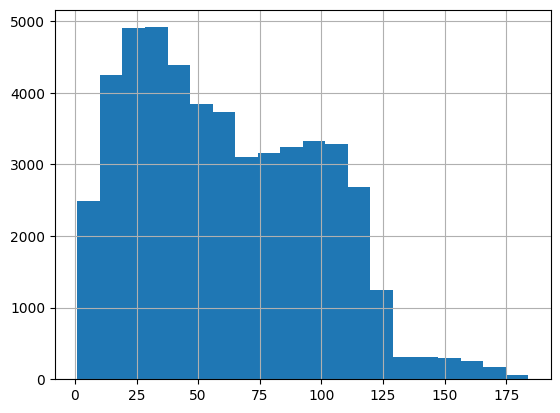

In [98]:
# Mostramos un histograma de la columna para ver la distribución visualmente

fact_viajes_limpio['pasajeros_subidos'].hist(bins=20)

Al tener únicamente 40 valores nulos en pasajeros_subidos (0,08% del total), y en vista del histograma con distribución asimétrica hacia la derecha (algunos viajes con número elevado de pasajeros), decidimos imputar los valores faltantes con la mediana, ya que representa un comportamiento más habitual que la media (se puede ver afectada por los valores extremos).

In [99]:
# Calculamos la mediana en una variable para imputarla después a los valores nulos

mediana = fact_viajes_limpio['pasajeros_subidos'].median()

fact_viajes_limpio['pasajeros_subidos'] = fact_viajes_limpio['pasajeros_subidos'].fillna(mediana)

In [100]:
# Convertimos a entero (No puede haber decimales en los pasajeros)

fact_viajes_limpio['pasajeros_subidos'] = fact_viajes_limpio['pasajeros_subidos'].astype('int64')

**consumo (de fact_viajes)**

Para esta variable tomamos un enfoque algo diferente, ya que el consumo puede depender de otras variables (que nos pueden ayudar a calcularlo), por lo que hay que comprobar con bastante atención si están en diferentes vehículos, o si alguno se repite (nos puede ayudar a descubrir fallos en vehículos)

In [101]:
# Imprimimos el resumen estadístico

fact_viajes_limpio['consumo'].describe()

count    48935.000000
mean         7.695104
std          6.221862
min          0.550000
25%          3.600000
50%          5.340000
75%          9.080000
max         32.860000
Name: consumo, dtype: float64

<Axes: >

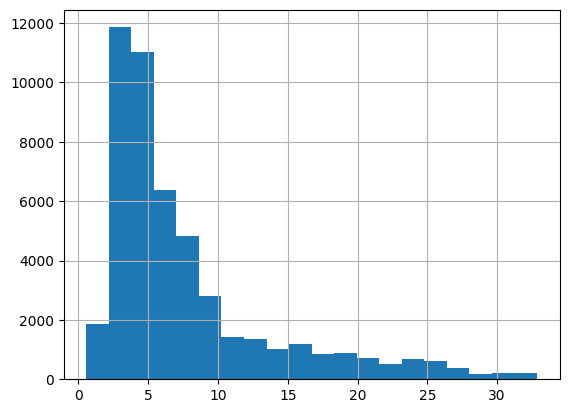

In [102]:
# Vemos la distribución de los consumos en un histograma

fact_viajes_limpio['consumo'].hist(bins=20)

In [103]:
# Buscamos la relación de los nulos con registros relevantes

fact_viajes_limpio.loc[
    fact_viajes_limpio['consumo'].isna(),
    ['vehiculo_id', 'km_recorridos', 'km_programados', 'consumo']
].head(15)

,vehiculo_id,km_recorridos,km_programados,consumo
36,38,9.7,9.7,NaN
288,38,19.8,19.8,NaN
301,9,19.8,19.8,NaN
314,22,8.9,8.9,NaN
316,24,9.7,9.7,NaN
329,37,9.7,9.7,NaN
343,9,9.7,9.7,NaN
474,14,11.2,11.2,NaN
483,23,12.6,12.6,NaN
524,22,15.0,15.0,NaN


In [104]:
# Vemos a que ID de vehiculo pertenecen los nulos

fact_viajes_limpio.loc[
    fact_viajes_limpio['consumo'].isna(),
    'vehiculo_id'
].value_counts().head(10)

vehiculo_id
23    110
39    107
9     105
7     102
37    102
14     98
29     96
24     93
8      86
22     84
Name: count, dtype: int64

In [105]:
# Viendo que los nulos están repartidos contamos la cantidad de viajes de cada vehículo

fact_viajes_limpio['vehiculo_id'].value_counts()

vehiculo_id
2     1191
3     1191
4     1191
5     1191
6     1191
7     1191
8     1191
9     1191
10    1191
11    1191
12    1191
13    1191
14    1191
15    1191
16    1191
17    1191
18    1191
19    1191
20    1191
21    1191
22    1190
23    1190
24    1190
25    1190
26    1190
27    1190
28    1190
29    1190
30    1190
31    1190
32    1190
33    1190
34    1190
35    1190
36    1190
37    1190
38    1190
39    1190
40    1190
41    1190
42    1190
1     1190
Name: count, dtype: int64

In [106]:
# Comprobamos la correlacion entre km_recorridos y consumo

fact_viajes_limpio[['km_recorridos','consumo']].corr()

,km_recorridos,consumo
km_recorridos,1.000000,0.441419
consumo,0.441419,1.000000


La variable consumo arroja 1.065 valores nulos (2,13 %), usamos un histograma para ver la distribución, observando que es asimetría positiva, con valores altos, incrementan la media respecto a la mediana. También hemos revisado una posible correlación con km_recorridos, siendo moderada (0,44), por lo que no podemos hacer una imputación basada en esta variable. Así que optamos por sustituir los valores nulos por la mediana (5,34), al ser más robusta frente a valores extremos.

In [107]:
# Calculamos la mediana en una variable para imputarla después a los valores nulos

mediana = fact_viajes_limpio['consumo'].median()

fact_viajes_limpio['consumo'] = fact_viajes_limpio['consumo'].fillna(mediana)

**categoria (de fact_mantenimiento)**

Empezamos viendo las categorías y nulos que existen, para ver si se pueden relacionar con otras columnas que podrían aportar información, y así rellenar los nulos deduciendo la categoría en función de otras variables

In [108]:
# Contamos las categorías y verificamos los nulos que hay

fact_mantenimiento_limpio['categoria'].value_counts(dropna=False)

categoria
Preventivo    359
Correctivo    332
Legal          85
Estetico       85
NaN            15
Name: count, dtype: int64

In [109]:
# Vemos específicamente las filas nulas

fact_mantenimiento_limpio.loc[
    fact_mantenimiento_limpio['categoria'].isna()
].head(15)

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
27,28,2,1,2022-02-09,2022-02-09,2022,2,ITV e Inspeccion,NaN,False,0,367231,213.34,ManteAuto S.L.,0
44,45,3,2,2024-01-30,2024-01-31,2024,1,Revision periodica,NaN,False,1,513003,103.64,Taller Oficial Mercedes,0
226,227,13,1,2022-03-14,2022-03-15,2022,3,Revision periodica,NaN,False,1,166144,142.11,FlotaService,0
279,280,15,3,2024-08-18,2024-08-19,2024,8,Carroceria y pintura,NaN,False,1,373996,392.02,TallerBus Norte,0
304,305,16,3,2024-03-01,2024-03-04,2024,3,Carroceria y pintura,NaN,False,3,216443,660.87,Taller Oficial Mercedes,0
316,317,16,3,2023-12-11,2023-12-11,2023,12,ITV e Inspeccion,NaN,False,0,340668,356.27,FlotaService,0
356,357,18,1,2022-04-13,2022-04-13,2022,4,ITV e Inspeccion,NaN,False,0,156165,258.38,ManteAuto S.L.,0
424,425,21,2,2022-01-02,2022-01-04,2022,1,Reparacion frenos,NaN,True,2,195046,999.23,Taller Oficial MAN,3
433,434,22,2,2024-06-06,2024-06-07,2024,6,ITV e Inspeccion,NaN,False,1,317132,320.06,Taller Oficial MAN,0
437,438,22,2,2024-01-26,2024-01-27,2024,1,ITV e Inspeccion,NaN,False,1,240474,252.94,Taller Oficial Mercedes,0


In [110]:
# Vemos la relación de los nulos con el tipo de mantenimiento

fact_mantenimiento_limpio.groupby('tipo_mantenimiento')['categoria'].value_counts()

tipo_mantenimiento    categoria 
Cambio aceite         Preventivo     90
Cambio neumaticos     Preventivo     79
Carroceria y pintura  Estetico       85
ITV e Inspeccion      Legal          85
Reparacion clima      Correctivo    102
Reparacion frenos     Correctivo     67
Reparacion motor      Correctivo     76
Revision bateria      Preventivo     94
Revision periodica    Preventivo     96
Sistema electrico     Correctivo     87
Name: count, dtype: int64

Con esta última celda vemos que la relación es directa, es decir no hay ambigüedad, ya que no existen categorias diferentes para un mismo tipo de mantenimiento.

In [111]:
#Creamos el diccionario de categorías y tipo de mantenimiento

dic_categoria = (
    fact_mantenimiento_limpio
    .dropna(subset=['categoria'])
    .drop_duplicates(subset=['tipo_mantenimiento'])
    .set_index('tipo_mantenimiento')['categoria']
)

In [112]:
# Rellenamos los nulos

fact_mantenimiento_limpio['categoria'] = (
    fact_mantenimiento_limpio['categoria']
    .fillna(
        fact_mantenimiento_limpio['tipo_mantenimiento'].map(dic_categoria)
    )
)

# Comprobamos que se ha hecho correctamente

fact_mantenimiento_limpio['categoria'].isna().sum()

np.int64(0)

categoria presentaba 15 valores nulos (1,71%), al ver que tiene una correspondencia univoca con tipo_mantenimiento (Ejemplos: "ITV e Inspección" → "Legal", "Revisión periódica" → "Preventivo"), imputamos los valores mediante esa correspondencia.

**combustible (de dim_vehiculo)**

A pesar de ser solo un valor, por lo que a priori puede parecer más sencillo, seguimos el mismo procedimiento, así que procedemos a investigar la variable faltante y las que se relacionan con ella:

In [113]:
# Vemos el nulo de combustible

dim_vehiculo_limpio[dim_vehiculo_limpio['combustible'].isna()]

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
31,32,6032 BUS,Mercedes-Benz Citaro,NaN,88,128,2019,2020,448858,2,136,True


In [114]:
# Comprobamos la relación entre modelo y combustible
# Para ver si aparece más veces el 'Mercedes-Benz Citaro'

dim_vehiculo_limpio.groupby('modelo')['combustible'].value_counts(dropna=False)

modelo                 combustible
BYD eBus-12            Electrico      6
Irizar ie bus          Electrico      3
Iveco Urbanway         Diésel         6
MAN Lions City         Diésel         3
MAN Lions City G       Diésel         3
Mercedes-Benz Citaro   Diésel         5
                       NaN            1
Mercedes-Benz eCitaro  Electrico      3
Scania Citywide        Diésel         3
Solaris Urbino 12      Diésel         3
Solaris Urbino 18      Diésel         3
Volvo 7900 Hybrid      Hibrido        6
Name: count, dtype: int64

Al ver directamente que tenemos otras 5 unidades del mismo modelo, decidimos imputar directamente ese combustible, descartando otras vías de investigación más complicadas.

In [115]:
# Imputamos el valor del combustible

dim_vehiculo_limpio.loc[
    dim_vehiculo_limpio['combustible'].isna(),
    'combustible'
] = 'Diésel'

# Comprobamos que se ha hecho correctamente

dim_vehiculo_limpio['combustible'].isna().sum()

np.int64(0)

La variable combustible presentaba un único valor nulo (2,22%). El vehículo corresponde al modelo Mercedes-Benz Citaro, del cual el resto de unidades (5) registradas son Diésel. Por tanto, el valor ausente se imputa como Diésel, por ser una correspondencia directa (y ser modelo diferente al Mercedes-Benz eCitaro).

**antiguedad_anos (de dim_conductor)**

En este caso vamos a buscar si existe relación directa para poder calcularlo

In [116]:
dim_conductor_limpio[dim_conductor_limpio['antiguedad_anos'].isna()]

,conductor_id,nombre,anno_incorporacion,antiguedad_anos,turno_habitual,depot_id,formacion,licencia_tipo,activo,ausencias_2024
9,10,Carmen Ruiz,2015,NaN,Mañana (06-14h),2,Basica + Articulado,D,True,15


In [117]:
# Comprobamos con otros conductores aleatorios si la antigüedad está bien calculada

dim_conductor_limpio.sample(10)[
    ['anno_incorporacion', 'antiguedad_anos']
]

,anno_incorporacion,antiguedad_anos
19,2016,8.0
18,2023,1.0
16,2013,11.0
1,2013,11.0
25,2008,16.0
23,2008,16.0
15,2018,6.0
17,2022,2.0
22,2019,5.0
28,2010,14.0


Comprobado que existe correlación directa, calculamos el valor del registro nulo:

In [118]:
dim_conductor_limpio.loc[
    dim_conductor_limpio['antiguedad_anos'].isna(),
    'antiguedad_anos'
] = (
    2024 -
    dim_conductor_limpio.loc[
        dim_conductor_limpio['antiguedad_anos'].isna(),
        'anno_incorporacion'
    ]
)

# Comprobamos que se ha hecho correctamente

dim_conductor_limpio['antiguedad_anos'].isna().sum()

np.int64(0)

antiguedad_anos solo tenía un único valor nulo (3,33% del total). Se comprueba que deriva directamente de anno_incorporacion: 2024 - anno_incorporacion. Por tanto se recalcula el valor faltante utilizando la relación, sin recurrir a imputaciones estadísticas.

**latitud (de dim_parada)**

Empezamos mostrando los todos demás datos de la fila con el registro nulo:

In [119]:
dim_parada_limpio[dim_parada_limpio['latitud'].isna()]

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
10,11,Parada Centro 11,Centro,Intermedia,NaN,-3.711652,True,True,True,True


In [120]:
# Vemos si existe otra parada con ese nombre

nombre_parada = dim_parada_limpio.loc[
    dim_parada_limpio['latitud'].isna(),
    'nombre_parada'
].iloc[0]

dim_parada_limpio[
    dim_parada_limpio['nombre_parada'] == nombre_parada
]

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
10,11,Parada Centro 11,Centro,Intermedia,NaN,-3.711652,True,True,True,True


Al no haber otra parada con el mismo nombre, buscamos coordenadas del barrio:

In [121]:
barrio = dim_parada_limpio.loc[
    dim_parada_limpio['latitud'].isna(),
    'barrio'
].iloc[0]

dim_parada_limpio[
    dim_parada_limpio['barrio'] == barrio
][['nombre_parada', 'latitud', 'longitud']]

,nombre_parada,latitud,longitud
4,Parada Poligono 5,40.410427,-3.715006
10,Parada Centro 11,NaN,-3.711652
21,Parada Centro 22,40.404825,-3.693176
32,Parada Centro 33,40.410742,-3.701975
43,Parada Centro 44,40.421511,-3.699699
54,Parada Centro 55,40.409491,-3.713152
65,Parada Centro 66,40.414018,-3.709669
76,Parada Centro 77,40.407477,-3.703253
87,Parada Centro 88,40.419484,-3.710815
98,Parada Centro 99,40.421423,-3.693469


Al presentar latitud un único nulo (0,83%) y no existir otra parada con el mismo nombre, el valor se imputa usando la latitud media de las paradas del mismo barrio (Centro). Esto permite conservar el registro utilizando información geográfica del entorno, evitando la eliminación de datos del sistema.

In [122]:
# Calculamos la media

dim_parada_limpio.groupby('barrio')['latitud'].mean()

barrio
Aeropuerto         40.435697
Barrio Norte       40.431325
Barrio Sur         40.399900
Centro             40.413899
Estacion          127.559858
Hospital           40.423042
Poligono           40.411640
Pueblo Este        40.420563
Pueblo Oeste       40.406213
Universidad        40.426021
Zona Comercial     40.410594
Name: latitud, dtype: float64

In [123]:
# Creamos la variable con la media del barrio Centro

media_centro = dim_parada_limpio.loc[
    dim_parada_limpio['barrio'] == 'Centro',
    'latitud'
].mean()

# Rellenamos el valor nulo

dim_parada_limpio.loc[
    dim_parada_limpio['latitud'].isna(),
    'latitud'
] = media_centro

# Comprobamos que se ha hecho correctamente

dim_parada_limpio['latitud'].isna().sum()

np.int64(0)

**accesible_silla (de dim_parada)**

Seguimos el mismo procedimiento que con los anteriores:

In [124]:
# Comprobamos el valor nulo

dim_parada_limpio[dim_parada_limpio['accesible_silla'].isna()]

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
22,23,Parada Barrio Norte 23,Barrio Norte,Intermedia,40.429211,-3.706099,NaN,False,False,True


In [125]:
# Volvemos a comprobar los valores de toda la columna

dim_parada_limpio['accesible_silla'].value_counts(dropna=False)

accesible_silla
True     102
False     17
NaN        1
Name: count, dtype: int64

Buscamos correlaciones con otras variables (tipo de parada, marquesina y panel informativo):

In [126]:
# Tipo de parada

dim_parada_limpio.groupby('tipo')['accesible_silla'].value_counts(dropna=False)

tipo            accesible_silla
Cabecera        True                5
                False               1
Intercambiador  True                6
Intermedia      True               91
                False              16
                NaN                 1
Name: count, dtype: int64

In [127]:
# Parada con marquesina (o no)

dim_parada_limpio.groupby('marquesina')['accesible_silla'].value_counts(dropna=False)

marquesina  accesible_silla
False       True               39
            False               5
            NaN                 1
True        True               63
            False              12
Name: count, dtype: int64

In [128]:
# Parada con panel informativo (o no)

dim_parada_limpio.groupby('panel_informacion')['accesible_silla'].value_counts(dropna=False)

panel_informacion  accesible_silla
False              True               54
                   False               5
                   NaN                 1
True               True               48
                   False              12
Name: count, dtype: int64

La variable accesible_silla presentaba un único valor nulo (0,83% del total). Analizando su relación con otras variables de parada (tipo de parada, marquesina y panel informativo) vemos que no existe patrón que ayude a deducir el valor real, usando la estadística (85% de paradas accesibles), imputamos el valor True, minimizando cualquier impacto sobre el dataset (no borramos una parada). Transformamos en valor booleano también.

In [129]:
dim_parada_limpio['accesible_silla'] = (
    dim_parada_limpio['accesible_silla']
    .fillna(True)
)

dim_parada_limpio['accesible_silla'] = (
    dim_parada_limpio['accesible_silla']
    .astype(bool)
)

# Comprobamos que se ha hecho correctamente

dim_parada_limpio['accesible_silla'].isna().sum()

C:\Users\alvar\AppData\Local\Temp\ipykernel_31692\4293238000.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(True)


np.int64(0)

### 05.4. Outliers y valores sospechosos

Recuperamos la tabla donde mencionamos los valores sospechosos anteriormente

| Dataset            |  Valores sospechosos              |
| ------------------ |  ----------------------           |
| fact_viajes        | retraso_salida_min=-99                       |
| fact_incidencias   | coste_estimado_eur = 14985'58        |
| fact_incidencias   | duracion_resolucion_min = 333        |
| fact_mantenimiento | coste_eur = -4083,03        |
| dim_vehiculo       | km_totales = -500               |
| dim_vehiculo       | anno_fabricacion = 2099                          |
| dim_parada       | latitud = 999                          |

* También existía el valor erróneo de `latitud = 999`, que ya corregimos anteriormente, por lo que únicamente se menciona aquí sin volver a tratarlo.

Sabiendo los que son vamos a ver la cantidad de veces que aparece cada uno, si existe algún patrón, si podemos "resolverlo" con otra columna para finalmente decidir qué hacemos con cada uno.

**retraso_salida_min = -99 (fact_viajes)**

In [130]:
# Mostramos las filas que contienen este valor en la columna 'retraso_salida_min'

fact_viajes_limpio[
    fact_viajes_limpio['retraso_salida_min'] == -99
]

,viaje_id,linea_id,vehiculo_id,conductor_id,parada_origen_id,parada_destino_id,fecha,anno,mes,dia_semana,es_festivo,franja_horaria,hora_salida_prog,hora_salida_real,hora_llegada_real,retraso_salida_min,duracion_real_min,pasajeros_subidos,ocupacion_pct,km_programados,km_recorridos,viaje_completado,consumo,tarifa_predominante_id
577,578,4,33,19,18,115,2023-02-14,2023,2,Martes,False,Mañana punta,08:20,08:32,09:22,-99,50,107,0.823,14.1,14.1,True,5.70,2
741,742,9,29,15,5,90,2022-01-23,2022,1,Domingo,True,Mañana punta,08:30,08:35,09:59,-99,84,80,0.640,19.8,19.8,True,23.11,9
1857,1858,8,11,11,40,70,2023-11-21,2023,11,Martes,False,Tarde punta,18:10,18:30,19:19,-99,49,74,0.578,12.6,12.6,True,3.52,1
2411,2412,3,19,5,16,103,2024-09-26,2024,9,Jueves,False,Mañana punta,08:20,08:21,09:01,-99,40,103,0.792,9.7,9.7,True,4.22,9
2910,2911,9,14,28,32,67,2022-05-28,2022,5,Sábado,True,Valle mañana,11:40,11:59,13:20,-99,81,28,0.224,19.8,19.8,True,25.16,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44373,44374,8,23,23,31,112,2024-07-22,2024,7,Lunes,False,Tarde punta,17:10,17:11,18:06,-99,55,111,0.854,12.6,12.6,True,14.87,2
45117,45118,9,11,11,32,46,2023-01-27,2023,1,Viernes,False,Tarde punta,17:30,17:32,18:48,-99,76,96,0.750,19.8,19.8,True,4.83,5
46741,46742,10,39,11,20,74,2023-01-08,2023,1,Domingo,True,Noche,22:20,22:26,23:21,-99,55,11,0.088,15.0,15.0,True,17.41,2
47368,47369,2,36,22,14,41,2023-09-08,2023,9,Viernes,False,Tarde punta,17:20,17:30,18:29,-99,59,78,0.422,11.2,11.2,True,3.79,4


Vemos que son bastantes, así que las contamos:

In [131]:
(fact_viajes_limpio['retraso_salida_min'] == -99).sum()

np.int64(80)

Sabiendo el número de veces que aparece, imprimimos ahora una muestra con algunas columnas que podrían darnos pistas para entender este valor:

In [132]:
fact_viajes_limpio.loc[
    fact_viajes_limpio['retraso_salida_min'] == -99,
    [
        'viaje_completado',
        'hora_salida_prog',
        'hora_salida_real',
        'duracion_real_min',
        'km_recorridos',
        'consumo',
        'pasajeros_subidos'
    ]
].head(20)

,viaje_completado,hora_salida_prog,hora_salida_real,duracion_real_min,km_recorridos,consumo,pasajeros_subidos
577,True,08:20,08:32,50,14.1,5.70,107
741,True,08:30,08:35,84,19.8,23.11,80
1857,True,18:10,18:30,49,12.6,3.52,74
2411,True,08:20,08:21,40,9.7,4.22,103
2910,True,11:40,11:59,81,19.8,25.16,28
2977,True,16:40,16:45,30,7.3,8.56,23
3057,True,00:10,00:10,64,15.0,5.08,33
3414,True,10:40,10:42,29,7.3,7.45,30
6621,True,15:00,15:00,44,11.2,12.89,27
7992,True,16:00,16:02,113,23.5,25.23,54


En base a la información que acabamos de extraer, y viendo que el valor -99 aparece únicamente 80 veces (de 50.000 registros), optamos por recalcular esos 80 valores en función de la información que aportan el resto de columnas, recalculando así el valor para preservar tanto la integridad del dataset como la calidad de la información.

Como solo tenemos que sustituir 80 valores, creamos dos variables temporales para modificar solo los campos necesarios una vez tengamos hechos todos los cálculos:

In [133]:
# Creamos variables temporales

hora_prog = pd.to_datetime(
    fact_viajes_limpio['hora_salida_prog'],
    format='%H:%M'
)

hora_real = pd.to_datetime(
    fact_viajes_limpio['hora_salida_real'],
    format='%H:%M'
)

# Calculamos la diferencia entre ambas (retraso)

retraso_calculado = (
    hora_real - hora_prog
).dt.total_seconds() / 60

# Comprobamos que el cálculo funciona correctamente

fact_viajes_limpio[
    ['hora_salida_prog',
     'hora_salida_real',
     'retraso_salida_min']
].head()

,hora_salida_prog,hora_salida_real,retraso_salida_min
0,17:50,18:09,19
1,07:10,07:23,13
2,12:30,12:30,0
3,20:50,20:50,0
4,18:10,18:18,8


In [134]:
# Modificamos únicamente los registros incorrectos (-99)

fact_viajes_limpio.loc[
    fact_viajes_limpio['retraso_salida_min'] == -99,
    'retraso_salida_min'
] = retraso_calculado[
    fact_viajes_limpio['retraso_salida_min'] == -99
]

In [135]:
# Comprobamos que la transformación se ha hecho correctamente

(fact_viajes_limpio['retraso_salida_min'] == -99).sum()

# Revisamos algunos registros aleatorios

fact_viajes_limpio.loc[
    fact_viajes_limpio['viaje_id'].isin([578, 742, 1858]),
    [
        'hora_salida_prog',
        'hora_salida_real',
        'retraso_salida_min'
    ]
]

,hora_salida_prog,hora_salida_real,retraso_salida_min
577,08:20,08:32,12
741,08:30,08:35,5
1857,18:10,18:30,20


**coste_estimado_eur = 14985.58 (de fact_incidencias)**

Este no tiene por qué ser un valor raro per se, volvemos a comprobar otros valores de la columna, si aparece más veces, etc...

In [136]:
# Mostramos los valores estadísticos de la columna para ver la distribución de datos

fact_incidencias_limpio['coste_estimado_eur'].describe()

count     4000.000000
mean      1198.774348
std       2575.401240
min          0.000000
25%          0.000000
50%        183.910000
75%       1204.757500
max      14985.580000
Name: coste_estimado_eur, dtype: float64

In [137]:
# Vemos las veces que aparece el valor

fact_incidencias_limpio[
    fact_incidencias_limpio['coste_estimado_eur'] ==  14985.58
]

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
1111,1112,7526,9,23,7,2024-11-03,2024,11,21:25,Accidente grave,Seguridad,Critica,True,5,False,14985.58


<Axes: >

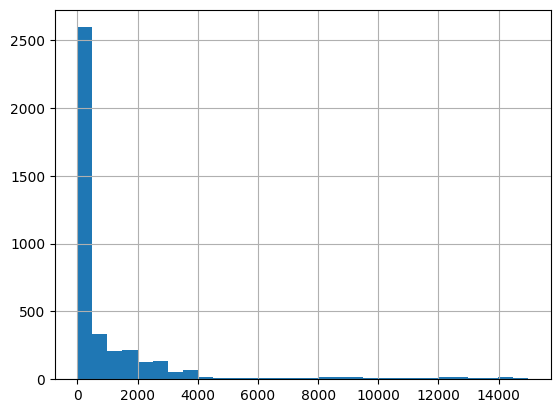

In [138]:
# Histograma para ver la distribución graficamente

fact_incidencias_limpio['coste_estimado_eur'].hist(bins=30)

In [139]:
# Vemos la relación de los valores sospechosos con registros relevantes

fact_incidencias_limpio.loc[
    fact_incidencias_limpio['coste_estimado_eur'] == 14985.58,
    [
        'tipo_incidencia',
        'severidad',
        'vehiculo_id',
        'fecha',
        'coste_estimado_eur'
    ]
]

,tipo_incidencia,severidad,vehiculo_id,fecha,coste_estimado_eur
1111,Accidente grave,Critica,9,2024-11-03,14985.58


In [140]:
# Valores estadísticos agrupados por tipo de incidencia para ver como se distribuyen

fact_incidencias_limpio.groupby('tipo_incidencia')['coste_estimado_eur'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_incidencia,,,,,,,,
Accidente grave,328.0,8470.416982,3868.042981,2004.83,4955.7150,8785.505,11827.6225,14985.58
Accidente leve,332.0,2286.725211,992.772242,511.82,1369.8900,2292.220,3159.5700,3999.91
Averia mecanica,347.0,1616.965677,805.066800,202.76,900.2700,1675.960,2332.6500,2977.68
Condiciones meteo,382.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
Fallo climatizacion,312.0,170.893494,73.105069,50.30,107.5550,168.545,236.0425,299.56
Fallo electrico,332.0,1169.687440,499.616846,301.88,699.7025,1195.890,1603.4350,1995.88
Huelga parcial,339.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
Obras calzada,340.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
Pasajero enfermo,311.0,53.679743,28.721420,0.27,28.7100,54.920,78.6900,99.91


El valor máximo identificado en la variable `coste_estimado_eur`, de 14.985,58 €, se consideró sospechoso en un principio por la diferente respecto al resto de datos observados. Analizando los registros se ve que pertenece a un Accidente grave, con severidad crítica y que necesitó retirada de vehículo. Además centrando el análisis en el tipo de incidencia se ve que los costes de otros Accidentes Graves son parecidos a este valor máximo y significativamente superiores al resto. Se concluye que el dato es correcto tras analizar el contexto por lo que se conserva.

**duracion_resolucion_min = 333 (de fact_incidencias)**

En vista de cómo acabamos de tratar en `coste_estimado_eur`, usaremos un enfoque similar que nos permita identificar si realmente se trata de un valor atípico y que hacemos con él:

In [141]:
# Localizamos el registro, para ver si aparece más de una vez y usamos el resto de columnas para ponerlo en contexto

fact_incidencias_limpio[
    fact_incidencias_limpio['duracion_resolucion_min'] == 333
]

,incidencia_id,viaje_id,vehiculo_id,conductor_id,linea_id,fecha,anno,mes,hora_incidencia,tipo_incidencia,categoria,severidad,requiere_retirada,duracion_resolucion_min,vehiculo_sustituto,coste_estimado_eur
2846,2847,49380,31,17,4,2024-06-24,2024,6,06:27,Averia mecanica,Vehiculo,Alta,True,333,True,2889.78


Vemos que solo aparece una vez, que corresponde a una avería mecánica con severidad alta, que requiere retirada y vehículo sustituto, con un coste estimado de 2.889,79 €

In [142]:
# Mostramos los valores estadísticos de la columna para ver la distribución de datos

fact_incidencias_limpio['duracion_resolucion_min'].describe()

count    4000.00000
mean       28.61075
std        34.06862
min         5.00000
25%         6.00000
50%        17.00000
75%        37.00000
max       333.00000
Name: duracion_resolucion_min, dtype: float64

<Axes: >

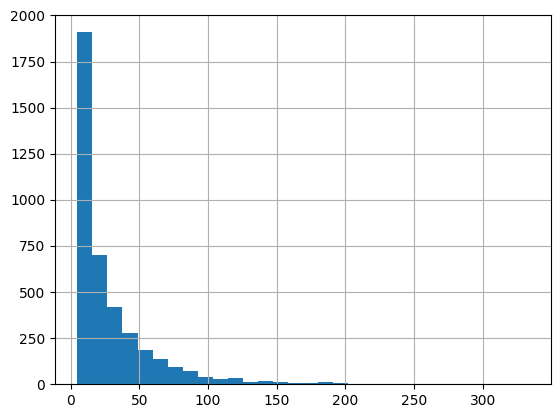

In [143]:
# Repetimos el proceso ahora de forma gráfica, con 30 intervalos

fact_incidencias_limpio['duracion_resolucion_min'].hist(bins=30)

In [144]:
# Hacemos la comparación agrupando por tipo de incidencia

fact_incidencias_limpio.groupby('tipo_incidencia')['duracion_resolucion_min'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_incidencia,,,,,,,,
Accidente grave,328.0,44.762195,47.521103,5.0,9.00,27.5,62.00,288.0
Accidente leve,332.0,42.141566,40.283750,5.0,12.75,30.0,55.00,267.0
Averia mecanica,347.0,41.253602,45.629815,5.0,11.00,26.0,55.00,333.0
Condiciones meteo,382.0,16.950262,14.929234,5.0,5.00,12.0,23.75,92.0
Fallo climatizacion,312.0,18.557692,17.438082,5.0,5.00,12.0,25.00,104.0
Fallo electrico,332.0,41.813253,38.833537,5.0,11.00,30.0,61.00,234.0
Huelga parcial,339.0,48.581121,50.666228,5.0,10.00,32.0,70.00,254.0
Obras calzada,340.0,17.535294,16.267362,5.0,5.00,11.0,23.00,107.0
Pasajero enfermo,311.0,17.064309,14.917052,5.0,5.00,12.0,22.00,83.0


In [145]:
# Y también por severidad

fact_incidencias_limpio.groupby('severidad')['duracion_resolucion_min'].describe()

,count,mean,std,min,25%,50%,75%,max
severidad,,,,,,,,
Alta,1350.0,43.449630,44.208114,5.0,11.0,29.0,60.0,333.0
Baja,624.0,18.794872,17.768429,5.0,5.0,12.0,25.0,104.0
Critica,328.0,44.762195,47.521103,5.0,9.0,27.5,62.0,288.0
Media,1698.0,17.300353,15.539575,5.0,5.0,12.0,23.0,121.0


In [146]:
# Ahora filtramos por las mayores duraciones de resolución de los incidentes

fact_incidencias_limpio.nlargest(
    10,
    'duracion_resolucion_min'
)[[
    'tipo_incidencia',
    'severidad',
    'duracion_resolucion_min',
    'coste_estimado_eur'
]]

,tipo_incidencia,severidad,duracion_resolucion_min,coste_estimado_eur
2846,Averia mecanica,Alta,333,2889.78
1055,Accidente grave,Critica,288,3435.17
2124,Averia mecanica,Alta,269,310.34
1624,Accidente leve,Alta,267,1218.60
2932,Accidente grave,Critica,256,8101.66
1536,Huelga parcial,Alta,254,0.00
1022,Huelga parcial,Alta,250,0.00
1503,Averia mecanica,Alta,250,1319.41
216,Huelga parcial,Alta,238,0.00
1935,Averia mecanica,Alta,236,1718.06


Una vez analizado el contexto de los 333 minutos con la resolución de las incidencias (Avería mecánica de severidad alta que implicó retirada del vehículo y su sustitución con un coste elevado (2.889,78 €)). Y centrándonos sólo en la duración, hay otros registros similares (236-288), por lo que es un valor atípico pero plausible, así que mantenemos el valor.

**coste_eur = -4083,03 (fact_mantenimiento)**

In [147]:
# Localizamos el valor en los registros

fact_mantenimiento_limpio[
    fact_mantenimiento_limpio['coste_eur'] == -4083.03
]

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
660,661,33,2,2022-01-08,2022-01-11,2022,1,Reparacion motor,Correctivo,True,3,258332,-4083.03,TallerBus Norte,12


In [148]:
# Observamos la distribución de los valores del coste

fact_mantenimiento_limpio['coste_eur'].describe()

count     876.000000
mean      742.520879
std       924.806659
min     -4083.030000
25%       237.712500
50%       455.085000
75%       922.100000
max      4987.720000
Name: coste_eur, dtype: float64

<Axes: >

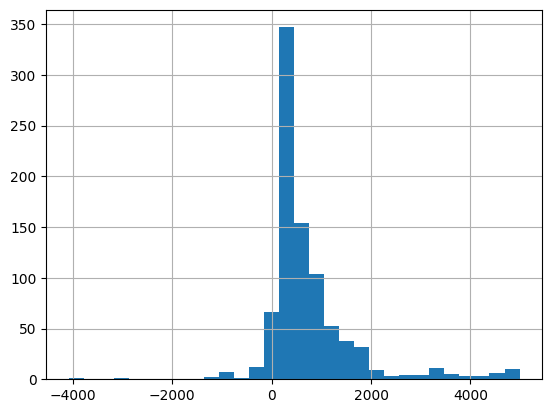

In [149]:
# Y ahora graficamente

fact_mantenimiento_limpio['coste_eur'].hist(bins=30)

In [150]:
# Buscamos los menores costes

fact_mantenimiento_limpio.nsmallest(
    10,
    'coste_eur'
)[[
    'tipo_mantenimiento',
    'coste_eur'
]]

,tipo_mantenimiento,coste_eur
660,Reparacion motor,-4083.03
315,Reparacion motor,-2942.78
104,Sistema electrico,-1077.87
717,Reparacion frenos,-1065.44
643,Sistema electrico,-1058.18
670,Cambio neumaticos,-1051.12
181,Cambio neumaticos,-1047.04
9,Reparacion clima,-866.90
195,Reparacion frenos,-810.99
821,Reparacion frenos,-806.40


In [151]:
# Y también los mayores

fact_mantenimiento_limpio.nlargest(
    10,
    'coste_eur'
)[[
    'tipo_mantenimiento',
    'coste_eur'
]]

,tipo_mantenimiento,coste_eur
650,Reparacion motor,4987.72
551,Reparacion motor,4968.74
781,Reparacion motor,4945.61
403,Reparacion motor,4894.29
42,Reparacion motor,4849.40
816,Reparacion motor,4789.20
291,Reparacion motor,4777.67
867,Reparacion motor,4722.02
694,Reparacion motor,4704.44
850,Reparacion motor,4702.65


In [152]:
# Hacemos la comparación por tipo de mantenimiento

fact_mantenimiento_limpio.groupby(
    'tipo_mantenimiento'
)['coste_eur'].describe()

,count,mean,std,min,25%,50%,75%,max
tipo_mantenimiento,,,,,,,,
Cambio aceite,90.0,173.294333,67.009147,-223.52,142.8800,179.370,216.9925,249.64
Cambio neumaticos,79.0,1168.011139,506.853302,-1051.12,903.8100,1194.040,1552.7750,1775.08
Carroceria y pintura,87.0,498.441149,217.567228,-506.81,350.4600,539.640,657.2650,799.15
ITV e Inspeccion,91.0,269.785495,116.585637,-361.30,225.9400,279.980,345.2500,397.89
Reparacion clima,102.0,573.754510,301.873736,-866.90,382.8000,608.670,792.5550,990.69
Reparacion frenos,69.0,758.157971,471.893103,-1065.44,645.2900,883.850,1036.5900,1181.63
Reparacion motor,76.0,2842.315132,1635.690298,-4083.03,1793.1875,3077.680,4062.8400,4987.72
Revision bateria,94.0,380.620532,166.456736,-349.48,312.1425,396.525,492.7125,599.36
Revision periodica,99.0,171.490808,95.695371,-297.65,127.9050,170.600,235.3450,298.88


Viendo todo este análisis, y que tenemos varios valores negativos en todas las categorías, cambiamos el enfoque, teniendo un par vías posibles con las que trabajar.

Por un lado que se trate de errores de carga, y que todos debieran ser positivos, y por otro lado que sean facturas rectificativas o de garantía (tenemos una columna de `garantia_meses`), por lo que los costes no se repercuten en la empresa y tiene sentido que sean negativos.

Trabajamos esta segunda hipótesis primero:

In [153]:
# Analizamos y clasificamos todos los costes negativos

fact_mantenimiento_limpio.loc[
    fact_mantenimiento_limpio['coste_eur'] < 0,
    [
        'tipo_mantenimiento',
        'coste_eur',
        'garantia_meses',
        'proveedor',
        'es_correctivo'
    ]
]

,tipo_mantenimiento,coste_eur,garantia_meses,proveedor,es_correctivo
9,Reparacion clima,-866.90,0,TallerBus Norte,True
104,Sistema electrico,-1077.87,12,ManteAuto S.L.,True
106,Revision periodica,-193.60,0,ManteAuto S.L.,False
114,Revision periodica,-211.69,0,Taller Oficial MAN,False
141,Carroceria y pintura,-222.12,0,Taller Oficial MAN,False
181,Cambio neumaticos,-1047.04,0,FlotaService,False
195,Reparacion frenos,-810.99,0,Taller Oficial MAN,True
250,ITV e Inspeccion,-361.30,0,FlotaService,False
265,Reparacion clima,-786.21,6,Taller Oficial Mercedes,True
315,Reparacion motor,-2942.78,0,TallerBus Norte,True


In [154]:
# Agrupamos si tiene garantía o no

fact_mantenimiento_limpio.groupby(
    fact_mantenimiento_limpio['coste_eur'] < 0
)[
    'garantia_meses'
].describe()

,count,mean,std,min,25%,50%,75%,max
coste_eur,,,,,,,,
False,851.0,2.083431,3.883764,0.0,0.0,0.0,3.0,12.0
True,25.0,1.800000,3.674235,0.0,0.0,0.0,0.0,12.0


In [155]:
# Contamos si son correctivos o no, en funció del valor del coste

fact_mantenimiento_limpio.groupby(
    fact_mantenimiento_limpio['coste_eur'] < 0
)[
    'es_correctivo'
].value_counts()

coste_eur  es_correctivo
False      False            526
           True             325
True       False             14
           True              11
Name: count, dtype: int64

In [156]:
# Repetimos con el proveedor

fact_mantenimiento_limpio.groupby(
    fact_mantenimiento_limpio['coste_eur'] < 0
)[
    'proveedor'
].value_counts()

coste_eur  proveedor              
False      ManteAuto S.L.             191
           Taller Oficial Mercedes    172
           TallerBus Norte            170
           Taller Oficial MAN         168
           FlotaService               150
True       Taller Oficial MAN           7
           TallerBus Norte              6
           FlotaService                 5
           Taller Oficial Mercedes      4
           ManteAuto S.L.               3
Name: count, dtype: int64

In [157]:
# Comprobamos los negativos que existen

(fact_mantenimiento_limpio['coste_eur'] < 0).sum()

np.int64(25)

Hay 25 registros con valores negativos en `coste_eur`, en los que no se han encontrado evidencias claras con los datos que disponemos de que pertenezcan a devoluciones o abonos de facturas. Se ha detectado una magnitud coherente con los costes habituales de las categorias de intervención, por lo que concluimos, tras hablar con la empresa, que se trata de errores de introducción de valores, así que pasamos todos los valores por debajo de cero a su valor positivo.

In [158]:
#Transformar valores negativos a absolutos

fact_mantenimiento_limpio.loc[
    fact_mantenimiento_limpio['coste_eur'] < 0,
    'coste_eur'
] = fact_mantenimiento_limpio.loc[
    fact_mantenimiento_limpio['coste_eur'] < 0,
    'coste_eur'
].abs()

#Comprobar que ya no hay negativos

(fact_mantenimiento_limpio['coste_eur'] < 0).sum()

#Comprobamos que el minimo ya está dentro de la lógica

fact_mantenimiento_limpio['coste_eur'].describe()

count     876.000000
mean      787.853162
std       886.460784
min        81.920000
25%       249.482500
50%       467.215000
75%       949.165000
max      4987.720000
Name: coste_eur, dtype: float64

**km_totales = -500 (dim_vehiculo)**

In [159]:
# Localizamos el registro

dim_vehiculo_limpio[
    dim_vehiculo_limpio['km_totales'] == -500
]

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
15,16,6016 BUS,Mercedes-Benz Citaro,Diésel,88,128,2015,2016,-500,3,140,True


In [160]:
# Mostramos las estadísticas generales ya que solo hay un registro

dim_vehiculo_limpio['km_totales'].describe()

count        45.000000
mean     361823.533333
std      157356.850166
min        -500.000000
25%      274345.000000
50%      379164.000000
75%      495798.000000
max      596622.000000
Name: km_totales, dtype: float64

<Axes: >

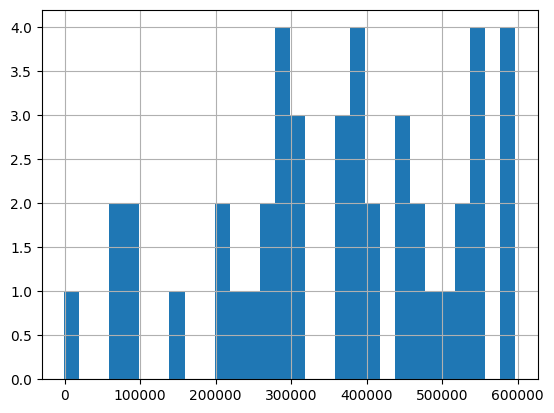

In [161]:
# Mostramos la distribución de forma gráfica

dim_vehiculo_limpio['km_totales'].hist(bins=30)

In [162]:
# Mostramos los km menores y el resto de columnas

dim_vehiculo_limpio.nsmallest(
    10,
    'km_totales'
)

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
15,16,6016 BUS,Mercedes-Benz Citaro,Diésel,88,128,2015,2016,-500,3,140,True
36,37,6037 BUS,BYD eBus-12,Electrico,90,130,2020,2021,78276,2,0,True
37,38,6038 BUS,BYD eBus-12,Electrico,90,130,2023,2024,78418,1,0,True
34,35,6035 BUS,Solaris Urbino 12,Diésel,85,125,2014,2015,80434,2,131,True
43,44,6044 BUS,Mercedes-Benz eCitaro,Electrico,85,125,2022,2023,92213,1,0,False
11,12,6012 BUS,MAN Lions City,Diésel,88,128,2016,2017,138914,2,110,True
44,45,6045 BUS,Scania Citywide,Diésel,88,128,2016,2017,209784,1,101,False
22,23,6023 BUS,BYD eBus-12,Electrico,90,130,2023,2024,216889,3,0,True
35,36,6036 BUS,Solaris Urbino 18,Diésel,145,185,2018,2019,223061,2,125,True
2,3,6003 BUS,Iveco Urbanway,Diésel,90,130,2018,2019,256606,2,133,True


In [163]:
# Y los mayores

dim_vehiculo_limpio.nlargest(
    10,
    'km_totales'
)

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
24,25,6025 BUS,Volvo 7900 Hybrid,Hibrido,88,128,2020,2021,596622,2,75,True
0,1,6001 BUS,Mercedes-Benz Citaro,Diésel,88,128,2017,2018,586265,1,127,True
4,5,6005 BUS,Solaris Urbino 12,Diésel,85,125,2014,2015,581756,2,119,True
21,22,6022 BUS,BYD eBus-12,Electrico,90,130,2022,2023,579298,2,0,True
14,15,6015 BUS,Scania Citywide,Diésel,88,128,2016,2017,548216,3,115,True
41,42,6042 BUS,MAN Lions City,Diésel,88,128,2016,2017,543152,1,105,True
29,30,6030 BUS,Scania Citywide,Diésel,88,128,2017,2018,538557,2,134,True
18,19,6019 BUS,Iveco Urbanway,Diésel,90,130,2018,2019,537115,1,133,True
38,39,6039 BUS,Irizar ie bus,Electrico,85,125,2024,2025,534125,1,0,True
19,20,6020 BUS,Solaris Urbino 12,Diésel,85,125,2016,2017,528634,1,107,True


Solo existe un valor negativo en km_totales, corresponde al vehiculo con id 16, Mercedes-Benz Citaro Diesel de 2015, que entró a la empresa en 2016. Vamos a intentar imputar el dato con las lecturas de odometro de las revisiones/mantenimientos y sumando los viajes que ha realizado:

In [164]:
# Creamos el dataset paralelo

viajes_vehiculo_16 = fact_viajes[
    fact_viajes['vehiculo_id'] == 16
].copy()

viajes_vehiculo_16.shape

(1191, 24)

In [165]:
# Sacamos el historico del vehículo, para ver entre que fechas tiene servicios
# Primero los más antiguos

viajes_vehiculo_16[['vehiculo_id', 'fecha']].sort_values('fecha').head()

,vehiculo_id,fecha
20426,16,2022-01-01
28490,16,2022-01-01
10682,16,2022-01-03
32144,16,2022-01-03
5894,16,2022-01-04


In [166]:
# Después los más recientes

viajes_vehiculo_16[['vehiculo_id', 'fecha']].sort_values('fecha').tail()

,vehiculo_id,fecha
3374,16,2024-12-27
12446,16,2024-12-27
2240,16,2024-12-28
14504,16,2024-12-28
6608,16,2024-12-30


In [167]:
# Rescatamos los nombres de las columnas para ver cual hace referencia a los km en el dataset original

fact_viajes.columns.tolist()

['viaje_id',
 'linea_id',
 'vehiculo_id',
 'conductor_id',
 'parada_origen_id',
 'parada_destino_id',
 'fecha',
 'anno',
 'mes',
 'dia_semana',
 'es_festivo',
 'franja_horaria',
 'hora_salida_prog',
 'hora_salida_real',
 'hora_llegada_real',
 'retraso_salida_min',
 'duracion_real_min',
 'pasajeros_subidos',
 'ocupacion_pct',
 'km_programados',
 'km_recorridos',
 'viaje_completado',
 'consumo',
 'tarifa_predominante_id']

In [168]:
# Sacamos los km_recorridos del vehiculo

viajes_vehiculo_16['km_recorridos'].describe()

count    1191.000000
mean       13.924542
std         4.957788
min         2.410000
25%         9.700000
50%        12.600000
75%        18.400000
max        23.500000
Name: km_recorridos, dtype: float64

In [169]:
# Y obtenemos la suma de los km_recorridos del vehiculo en el periodo de estudio

viajes_vehiculo_16['km_recorridos'].sum()

np.float64(16584.13)

A partir de ahí empezamos la búsqueda en el mantenimiento:

In [170]:
fact_mantenimiento.columns.tolist()

['mantenimiento_id',
 'vehiculo_id',
 'depot_id',
 'fecha_entrada',
 'fecha_salida',
 'anno',
 'mes',
 'tipo_mantenimiento',
 'categoria',
 'es_correctivo',
 'dias_fuera_servicio',
 'km_en_revision',
 'coste_eur',
 'proveedor',
 'garantia_meses']

In [171]:
mantenimiento_vehiculo_16 = fact_mantenimiento[
    fact_mantenimiento['vehiculo_id'] == 16
].copy()

# Ordenamos por fecha de entrada

mantenimiento_vehiculo_16.sort_values('fecha_entrada')

,mantenimiento_id,vehiculo_id,depot_id,fecha_entrada,fecha_salida,anno,mes,tipo_mantenimiento,categoria,es_correctivo,dias_fuera_servicio,km_en_revision,coste_eur,proveedor,garantia_meses
308,309,16,3,2022-05-25,2022-05-26,2022,5,Revision periodica,Preventivo,False,1,36708,175.03,FlotaService,0
298,299,16,3,2022-09-18,2022-09-19,2022,9,Sistema electrico,Correctivo,True,1,147072,1339.51,TallerBus Norte,0
306,307,16,3,2022-12-26,2022-12-30,2022,12,Reparacion frenos,Correctivo,True,4,241377,1006.20,ManteAuto S.L.,12
310,311,16,3,2023-01-22,2023-01-23,2023,1,Sistema electrico,Correctivo,True,1,202425,1133.69,FlotaService,12
309,310,16,3,2023-01-25,2023-01-25,2023,1,Revision bateria,Preventivo,False,0,541004,258.82,FlotaService,0
299,300,16,3,2023-04-06,2023-04-06,2023,4,ITV e Inspeccion,Legal,False,0,29972,307.48,Taller Oficial Mercedes,0
305,306,16,3,2023-04-24,2023-04-25,2023,4,Revision bateria,Preventivo,False,1,393411,463.01,ManteAuto S.L.,0
315,316,16,3,2023-05-02,2023-05-10,2023,5,Reparacion motor,Correctivo,True,8,361022,-2942.78,TallerBus Norte,0
311,312,16,3,2023-05-28,2023-05-28,2023,5,Revision periodica,Preventivo,False,0,354152,269.51,Taller Oficial Mercedes,0
302,303,16,3,2023-07-12,2023-07-15,2023,7,Carroceria y pintura,Estetico,False,3,25510,539.64,Taller Oficial Mercedes,0


In [172]:
mantenimiento_vehiculo_16 = mantenimiento_vehiculo_16.sort_values(
    'fecha_entrada'
).copy()

mantenimiento_vehiculo_16['incremento_km'] = (
    mantenimiento_vehiculo_16['km_en_revision'].diff()
)

mantenimiento_vehiculo_16[
    [
        'fecha_entrada',
        'km_en_revision',
        'incremento_km'
    ]
]

,fecha_entrada,km_en_revision,incremento_km
308,2022-05-25,36708,NaN
298,2022-09-18,147072,110364.0
306,2022-12-26,241377,94305.0
310,2023-01-22,202425,-38952.0
309,2023-01-25,541004,338579.0
299,2023-04-06,29972,-511032.0
305,2023-04-24,393411,363439.0
315,2023-05-02,361022,-32389.0
311,2023-05-28,354152,-6870.0
302,2023-07-12,25510,-328642.0


Con los km de los viajes, unicamente obtenemos el aumento en el periodo estudiado (2022 a 2024), pero al intentar estudiar el historico del odometro por los mantenimientos vemos que no tiene un crecimiento consistente por lo que no podemos averiguar de forma fiable como sustituir el valor de -500... Tras hablarlo con la empresa, comprobamos que se trata de un error en la introducción de datos, por lo que se opta por dejar la base del numero, pero transformarlo en 500.000 para que tenga consistencia, aunque sea un valor "forzado".

In [173]:
# Transformamos el valor detectado erroneo en positivo

dim_vehiculo_limpio.loc[
    dim_vehiculo_limpio['km_totales'] == -500,
    'km_totales'
] = 500000

In [174]:
# Comprobamos que se ha realizado correctamente

dim_vehiculo_limpio[
    dim_vehiculo_limpio['vehiculo_id'] == 16
][[
    'vehiculo_id',
    'modelo',
    'anno_fabricacion',
    'anno_incorporacion',
    'km_totales'
]]

,vehiculo_id,modelo,anno_fabricacion,anno_incorporacion,km_totales
15,16,Mercedes-Benz Citaro,2015,2016,500000


Comprobamos la inconsistencia en los mantenimiento para el resto de vehículos:

In [175]:
mantenimiento_ordenado = fact_mantenimiento.sort_values(
    ['vehiculo_id', 'fecha_entrada']
).copy()

mantenimiento_ordenado['incremento_km'] = (
    mantenimiento_ordenado
    .groupby('vehiculo_id')['km_en_revision']
    .diff()
)

mantenimiento_ordenado[
    mantenimiento_ordenado['incremento_km'] < 0
][
    [
        'vehiculo_id',
        'fecha_entrada',
        'km_en_revision',
        'incremento_km'
    ]
]

(
    mantenimiento_ordenado['incremento_km'] < 0
).sum()

np.int64(420)

In [176]:
# Calculamos el % de registros con anomlías

incrementos_validos = mantenimiento_ordenado['incremento_km'].dropna()

(
    incrementos_validos < 0
).mean() * 100


np.float64(50.54151624548736)

In [177]:
# Vemos si los incrementos negativos se concentran en algunos vehículos o en todos

resumen_km_mantenimiento = (
    mantenimiento_ordenado
    .groupby('vehiculo_id')['incremento_km']
    .agg(
        total_registros='count',
        incrementos_negativos=lambda x: (x < 0).sum(),
        porcentaje_negativos=lambda x: (x < 0).mean() * 100
    )
    .sort_values('porcentaje_negativos', ascending=False)
)

resumen_km_mantenimiento

,total_registros,incrementos_negativos,porcentaje_negativos
vehiculo_id,,,
13,24,15,60.000000
15,19,12,60.000000
11,21,13,59.090909
42,28,17,58.620690
26,29,17,56.666667
36,15,9,56.250000
22,28,16,55.172414
16,19,11,55.000000
17,21,12,54.545455


Se analizó la evolución de km_en_revision para comprobar si podía utilizarse como registro acumulativo del kilometraje de los vehículos. Al ordenar los mantenimientos cronológicamente por vehículo y calcular la diferencia entre lecturas consecutivas, se observó que aproximadamente la mitad de los incrementos son negativos frente a los válidos (420 sobre 831).

La elevada frecuencia de descensos indica que km_en_revision no puede interpretarse de forma general como un kilometraje acumulado fiable. En consecuencia, no se considera adecuado utilizar esta variable directamente para reconstruir o corregir km_totales de dim_vehiculo.

Vamos a analizar los km_en_revision divididos por vehículo y año para intentar analizar de forma independiente cada vehículo y ver que hacer con lo que vamos a obtener:

In [178]:
# Evolución de km por vehículo

mantenimiento_ordenado = (
    fact_mantenimiento
    .sort_values(['vehiculo_id', 'fecha_entrada'])
    .copy()
)

mantenimiento_ordenado['incremento_km'] = (
    mantenimiento_ordenado
    .groupby('vehiculo_id')['km_en_revision']
    .diff()
)

mantenimiento_ordenado['variacion_pct'] = (
    mantenimiento_ordenado
    .groupby('vehiculo_id')['km_en_revision']
    .pct_change() * 100
)

In [179]:
resumen_km_anual = (
    mantenimiento_ordenado
    .groupby(['vehiculo_id', 'anno'])['km_en_revision']
    .agg(
        registros='count',
        minimo='min',
        maximo='max',
        media='mean'
    )
    .reset_index()
)

resumen_km_anual.head(20)

,vehiculo_id,anno,registros,minimo,maximo,media
0,1,2022,3,234170,533556,359123.666667
1,1,2023,1,240059,240059,240059.000000
2,1,2024,4,278454,512844,397869.750000
3,2,2022,8,21141,440170,279350.500000
4,2,2023,8,48957,471997,272850.250000
5,2,2024,8,96111,541913,253476.000000
6,3,2022,5,38364,427088,263155.600000
7,3,2023,4,189091,522237,330211.500000
8,3,2024,6,24897,529309,350437.000000
9,4,2022,4,120512,415039,283120.000000


In [180]:
# Mostramos el primer y ultimo registro de kilometraje de cada vehículo

evolucion_km = (
    mantenimiento_ordenado
    .groupby('vehiculo_id')
    .agg(
        primer_km=('km_en_revision', 'first'),
        ultimo_km=('km_en_revision', 'last'),
        registros=('km_en_revision', 'count')
    )
)

evolucion_km['diferencia'] = (
    evolucion_km['ultimo_km'] - evolucion_km['primer_km']
)

evolucion_km

,primer_km,ultimo_km,registros,diferencia
vehiculo_id,,,,
1,309645,307110,8,-2535
2,363845,541913,24,178068
3,60650,513253,15,452603
4,196889,147022,11,-49867
5,500023,359855,23,-140168
6,193422,200923,29,7501
7,362779,348728,19,-14051
8,437880,493372,24,55492
9,143388,528972,19,385584


In [181]:
# Calculamos el % de vehículos que terminan con menos km de los que inician 

(evolucion_km['diferencia'] < 0).sum()

np.int64(23)

Una vez demostrado, tras estudiar en detalle toda la información disponible, que los errores en la recogida de datos no es una cosa aislada, aunque a priori parecian estar bien, y no se habian detectado como errores, se informa a la empresa para que revisen posibles problemas en la obtención, grabación, o lectura de datos, y así evitar las inconsistencias a futuro.

**anno_fabricacion = 2099 (dim_vehiculo)**

In [182]:
# Localizamos el registro

dim_vehiculo_limpio[
    dim_vehiculo_limpio['anno_fabricacion'] == 2099
]

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
7,8,6008 BUS,BYD eBus-12,Electrico,90,130,2099,2024,365568,2,0,True


In [183]:
# Estadisticas año de fabricación

dim_vehiculo_limpio['anno_fabricacion'].describe()

count      45.000000
mean     2020.822222
std        12.227556
min      2014.000000
25%      2017.000000
50%      2019.000000
75%      2021.000000
max      2099.000000
Name: anno_fabricacion, dtype: float64

<Axes: >

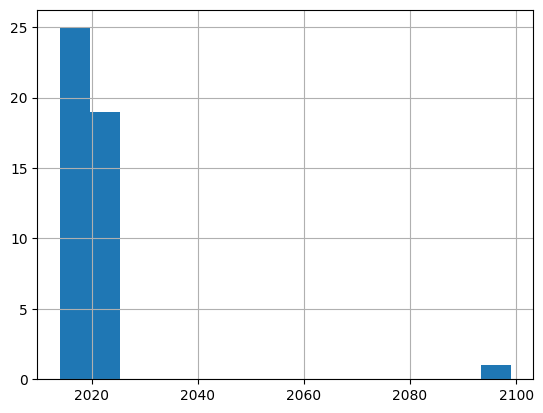

In [184]:
# Mostamos la distribución de forma gráfica

dim_vehiculo_limpio['anno_fabricacion'].hist(bins=15)

In [185]:
# Listamos todos los años presentes en la columna

dim_vehiculo_limpio['anno_fabricacion'].value_counts().sort_index()

anno_fabricacion
2014    2
2015    2
2016    6
2017    3
2018    6
2019    6
2020    7
2021    2
2022    4
2023    3
2024    3
2099    1
Name: count, dtype: int64

Vemos que no existen otros años futuros....

In [186]:
# Relacionamos con el año de incorpación

dim_vehiculo_limpio.loc[
    dim_vehiculo_limpio['anno_fabricacion'] == 2099,
    [
        'modelo',
        'anno_fabricacion',
        'anno_incorporacion',
        'km_totales'
    ]
]

,modelo,anno_fabricacion,anno_incorporacion,km_totales
7,BYD eBus-12,2099,2024,365568


In [187]:
# Buscamos relacion entre modelo y año de fabricación

dim_vehiculo_limpio.groupby(
    'modelo'
)['anno_fabricacion'].describe()

,count,mean,std,min,25%,50%,75%,max
modelo,,,,,,,,
BYD eBus-12,6.0,2034.500000,31.627520,2020.0,2020.50,2022.5,2023.00,2099.0
Irizar ie bus,3.0,2023.666667,0.577350,2023.0,2023.50,2024.0,2024.00,2024.0
Iveco Urbanway,6.0,2018.166667,1.329160,2016.0,2018.00,2018.0,2018.75,2020.0
MAN Lions City,3.0,2016.333333,0.577350,2016.0,2016.00,2016.0,2016.50,2017.0
MAN Lions City G,3.0,2020.000000,0.000000,2020.0,2020.00,2020.0,2020.00,2020.0
Mercedes-Benz Citaro,6.0,2017.166667,1.834848,2015.0,2015.50,2017.5,2018.75,2019.0
Mercedes-Benz eCitaro,3.0,2022.666667,1.154701,2022.0,2022.00,2022.0,2023.00,2024.0
Scania Citywide,3.0,2016.333333,0.577350,2016.0,2016.00,2016.0,2016.50,2017.0
Solaris Urbino 12,3.0,2014.666667,1.154701,2014.0,2014.00,2014.0,2015.00,2016.0


El valor 2099 constituye un error evidente, ya que implica que el vehículo fue fabricado décadas después de su incorporación al servicio (2024), incumpliendo la consistencia temporal. Seguramente se trate de un error de captura, buscamos tener la información suficiente para inferir con certeza el año correcto.

Nos centramos únicamente en los modelos BYD eBus-12, para ver si a partir de ahí podemos sacar más información:

In [188]:
dim_vehiculo_limpio[
    dim_vehiculo_limpio['modelo'] == 'BYD eBus-12'
]

,vehiculo_id,matricula,modelo,combustible,capacidad_sentados,capacidad_total,anno_fabricacion,anno_incorporacion,km_totales,depot_id,emisiones_co2_gkm,en_servicio
6,7,6007 BUS,BYD eBus-12,Electrico,90,130,2020,2021,447562,3,0,True
7,8,6008 BUS,BYD eBus-12,Electrico,90,130,2099,2024,365568,2,0,True
21,22,6022 BUS,BYD eBus-12,Electrico,90,130,2022,2023,579298,2,0,True
22,23,6023 BUS,BYD eBus-12,Electrico,90,130,2023,2024,216889,3,0,True
36,37,6037 BUS,BYD eBus-12,Electrico,90,130,2020,2021,78276,2,0,True
37,38,6038 BUS,BYD eBus-12,Electrico,90,130,2023,2024,78418,1,0,True


A simple vista podemos formular la hipótesis de que salvo el registro erróneo, todas la unidades de BYD eBus-12 confirman que `anno_incorporacion` = `anno_fabriacion` + 1. Por lo que procedemos a comprobar si la misma hipótesis se cumple para el resto de marcas/modelos.

In [189]:
dim_vehiculo_limpio.sort_values(
    ['modelo', 'anno_fabricacion']
)[[
    'vehiculo_id',
    'modelo',
    'anno_fabricacion',
    'anno_incorporacion',
    'km_totales'
]]

,vehiculo_id,modelo,anno_fabricacion,anno_incorporacion,km_totales
6,7,BYD eBus-12,2020,2021,447562
36,37,BYD eBus-12,2020,2021,78276
21,22,BYD eBus-12,2022,2023,579298
22,23,BYD eBus-12,2023,2024,216889
37,38,BYD eBus-12,2023,2024,78418
7,8,BYD eBus-12,2099,2024,365568
23,24,Irizar ie bus,2023,2024,309249
8,9,Irizar ie bus,2024,2025,368635
38,39,Irizar ie bus,2024,2025,534125
32,33,Iveco Urbanway,2016,2017,458930


Apoyados en la hipotésis que hemos formulado de anno_fabricacion + 1 = anno_incorporacion, y sabiendo que tenemos registros de mantenimientos, vajes, etc... Buscamos información del vehículo 8 a estos respectos para ver cuando fue el primer viaje que realizó y de ahí imputar el valor:

In [190]:
viajes_vehiculo_8 = fact_viajes[
    fact_viajes['vehiculo_id'] == 8
].copy()

viajes_vehiculo_8['fecha'].min()

'2022-01-01'

Conectamos ambos caminos para obtener la conclusión. Una vez validada la hipótesis de anno_fabricacion + 1 = anno_incorporacion, en vez de simplamente cambiar el dato, hemos recorrido el camino al revés, buscando cuando se tienen registros de los primeros viajes del vehículo y a partir de ahí restar un año, para dejar los datos correctos, tras hablarlo y validar la hipótesis también con la empresa.

In [191]:
# Modificamos año de incorporación y año de fabricación del vehículo 8 para que tenga sentido con el resto de datos

dim_vehiculo_limpio.loc[
    dim_vehiculo_limpio['vehiculo_id'] == 8,
    'anno_incorporacion'
] = 2022

dim_vehiculo_limpio.loc[
    dim_vehiculo_limpio['vehiculo_id'] == 8,
    'anno_fabricacion'
] = 2021

In [192]:
# Comprobamos los cambios

dim_vehiculo_limpio[
    dim_vehiculo_limpio['vehiculo_id'] == 8
][[
    'vehiculo_id',
    'modelo',
    'anno_fabricacion',
    'anno_incorporacion',
    'km_totales'
]]

,vehiculo_id,modelo,anno_fabricacion,anno_incorporacion,km_totales
7,8,BYD eBus-12,2021,2022,365568


El vehiculo_id = 8 presentaba un anno_fabricacion = 2099, valor incompatible con el resto de registros de la flota. Además, el vehículo figuraba con un anno_incorporacion = 2024. Al contrastar la información de la dimensión de vehículos con la tabla fact_viajes, se comprobó que el vehículo ya registraba viajes desde el año 2022. Por tanto, el año de incorporación de 2024 no era compatible con la actividad registrada en la tabla de hechos. Se estableció el año 2022 como año de incorporación del vehículo, al ser el primer año en el que se dispone de registros de viajes para este vehículo. A partir de este dato, se estableció como año de fabricación 2021, siguiendo la relación observada de un año entre fabricación e incorporación..

Por ultimo comprobamos si puede haber errores en el resto de vehículos y que tengan registros, para al igual que con los km, avisar a la empresa para qur revisen los protocolos de recogida, grabación, etc... de los datos

In [193]:
fact_viajes_vehiculo = fact_viajes.merge(
    dim_vehiculo_limpio[
        [
            'vehiculo_id',
            'anno_fabricacion',
            'anno_incorporacion'
        ]
    ],
    on='vehiculo_id',
    how='left'
)

fact_viajes_vehiculo[
    fact_viajes_vehiculo['anno'] < fact_viajes_vehiculo['anno_incorporacion']
].shape

(7136, 26)

In [194]:
viajes_antes_incorporacion = (
    fact_viajes_vehiculo[
        fact_viajes_vehiculo['anno'] <
        fact_viajes_vehiculo['anno_incorporacion']
    ]
    .groupby('vehiculo_id')
    .agg(
        primer_viaje=('fecha', 'min'),
        anno_incorporacion=('anno_incorporacion', 'first'),
        viajes_anteriores=('viaje_id', 'count')
    )
    .sort_values('viajes_anteriores', ascending=False)
)

viajes_antes_incorporacion

,primer_viaje,anno_incorporacion,viajes_anteriores
vehiculo_id,,,
9,2022-01-02,2025,1191
39,2022-01-01,2025,1190
29,2022-01-01,2025,1190
38,2022-01-01,2024,809
24,2022-01-01,2024,801
23,2022-01-01,2024,779
22,2022-01-02,2023,409
14,2022-01-01,2023,390
26,2022-01-01,2023,377


<Axes: >

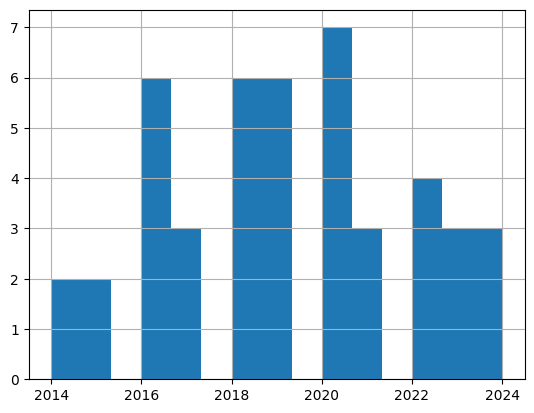

In [195]:
# Volvemos a mostrar la distribución graficamente para comprobar el cambio de año de fabricación

dim_vehiculo_limpio['anno_fabricacion'].hist(bins=15)

<Axes: >

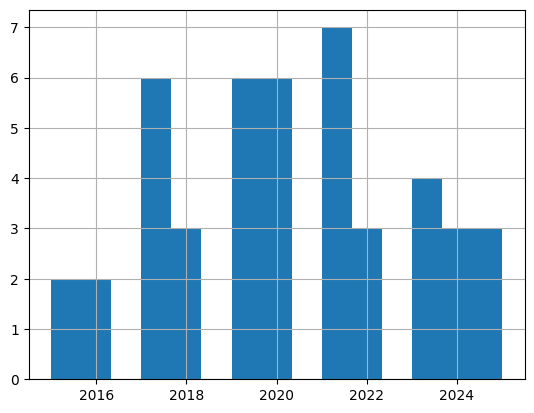

In [196]:
# también mostramos la distribución gráfica para comprobar el cambio en el año de incorporación

dim_vehiculo_limpio['anno_incorporacion'].hist(bins=15)

**latitud = 999 (dim_parada)**

In [197]:
# Mostramos la fila que contiene el valor de latitud 999

dim_parada_limpio[
    dim_parada_limpio['latitud'] == 999
]

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
60,61,Parada Estacion 61,Estacion,Intermedia,999.0,-3.690494,True,True,True,True


Al no haber otra parada con el mismo nombre, buscamos coordenadas a través del barrio:

In [198]:
# Comparamos las paradas del barrio (Estación)

dim_parada_limpio[
    dim_parada_limpio['barrio'] == barrio
][
    ['parada_id', 'nombre_parada', 'latitud', 'longitud']
].sort_values('longitud')

,parada_id,nombre_parada,latitud,longitud
4,5,Parada Poligono 5,40.410427,-3.715006
54,55,Parada Centro 55,40.409491,-3.713152
10,11,Parada Centro 11,40.413899,-3.711652
87,88,Parada Centro 88,40.419484,-3.710815
65,66,Parada Centro 66,40.414018,-3.709669
76,77,Parada Centro 77,40.407477,-3.703253
32,33,Parada Centro 33,40.410742,-3.701975
43,44,Parada Centro 44,40.421511,-3.699699
109,110,Parada Centro 110,40.419591,-3.694619
98,99,Parada Centro 99,40.421423,-3.693469


In [199]:
# Comrpobamos si hay patrones entre latitud y longitud para ver si podemos imputar el valor de latitud

dim_parada_limpio[
    dim_parada_limpio['barrio'] == barrio
][
    ['parada_id', 'nombre_parada', 'latitud', 'longitud']
].sort_values('parada_id')

,parada_id,nombre_parada,latitud,longitud
4,5,Parada Poligono 5,40.410427,-3.715006
10,11,Parada Centro 11,40.413899,-3.711652
21,22,Parada Centro 22,40.404825,-3.693176
32,33,Parada Centro 33,40.410742,-3.701975
43,44,Parada Centro 44,40.421511,-3.699699
54,55,Parada Centro 55,40.409491,-3.713152
65,66,Parada Centro 66,40.414018,-3.709669
76,77,Parada Centro 77,40.407477,-3.703253
87,88,Parada Centro 88,40.419484,-3.710815
98,99,Parada Centro 99,40.421423,-3.693469


In [200]:
# Buscamos las paradas con la longitud más cercana a la parada con latitud 999 para ver si podemos imputar el valor de latitud

dim_parada_limpio[
    dim_parada_limpio['barrio'] == barrio
][
    ['parada_id', 'nombre_parada', 'latitud', 'longitud']
].assign(
    distancia_longitud=lambda x: abs(x['longitud'] - (-3.690494))
).sort_values('distancia_longitud')

,parada_id,nombre_parada,latitud,longitud,distancia_longitud
21,22,Parada Centro 22,40.404825,-3.693176,0.002682
98,99,Parada Centro 99,40.421423,-3.693469,0.002975
109,110,Parada Centro 110,40.419591,-3.694619,0.004125
43,44,Parada Centro 44,40.421511,-3.699699,0.009205
32,33,Parada Centro 33,40.410742,-3.701975,0.011481
76,77,Parada Centro 77,40.407477,-3.703253,0.012759
65,66,Parada Centro 66,40.414018,-3.709669,0.019175
87,88,Parada Centro 88,40.419484,-3.710815,0.020321
10,11,Parada Centro 11,40.413899,-3.711652,0.021158
54,55,Parada Centro 55,40.409491,-3.713152,0.022658


In [201]:
# Comprobamos la relación entre parada_id y las coordenadas
dim_parada_limpio[
    dim_parada_limpio['barrio'] == barrio
][
    ['parada_id', 'latitud', 'longitud']
].corr(numeric_only=True)

,parada_id,latitud,longitud
parada_id,1.000000,0.547729,0.389038
latitud,0.547729,1.000000,0.198174
longitud,0.389038,0.198174,1.000000


No se observa una relación suficientemente clara entre parada_id y la latitud, ni entre latitud y longitud, para poder reconstruir de forma fiable el valor ausente. Por tanto, se opta por imputar la latitud mediante la media de las paradas del barrio Estación.

In [202]:
# Excluimos el valor de latitud 999 y calculamos la media para el barrio Estación

media_estacion = dim_parada_limpio.loc[
    (dim_parada_limpio['barrio'] == barrio) &
    (dim_parada_limpio['latitud'] != 999),
    'latitud'
].mean()

media_estacion

np.float64(40.4138989)

In [203]:
# Corregimos el valor con la media calculada

dim_parada_limpio.loc[
    dim_parada_limpio['latitud'] == 999,
    'latitud'
] = media_estacion

# Comprobamos que se ha hecho correctamente

dim_parada_limpio[
    dim_parada_limpio['parada_id'] == 61
]

,parada_id,nombre_parada,barrio,tipo,latitud,longitud,accesible_silla,marquesina,panel_informacion,activa
60,61,Parada Estacion 61,Estacion,Intermedia,40.413899,-3.690494,True,True,True,True


Con el valor sospechoso de la latitud (999) en la parada 61 se investigó la posibilidad de reconstruirlo a partir de otras paradas del mismo barrio y de la relación entre coordenadas e identificador de parada, sin encontrar un patrón suficientemente fiable que permitiera determinar la coordenada exacta. Por este motivo se imputó utilizando la media de latitud de las paradas del barrio Estacion, excluyendo previamente el valor erróneo.

## 06. Visualizaciones

**Visualización 1**

***Pregunta de negocio:** ¿Cómo evoluciona la demanda del servicio durante el periodo analizado?*

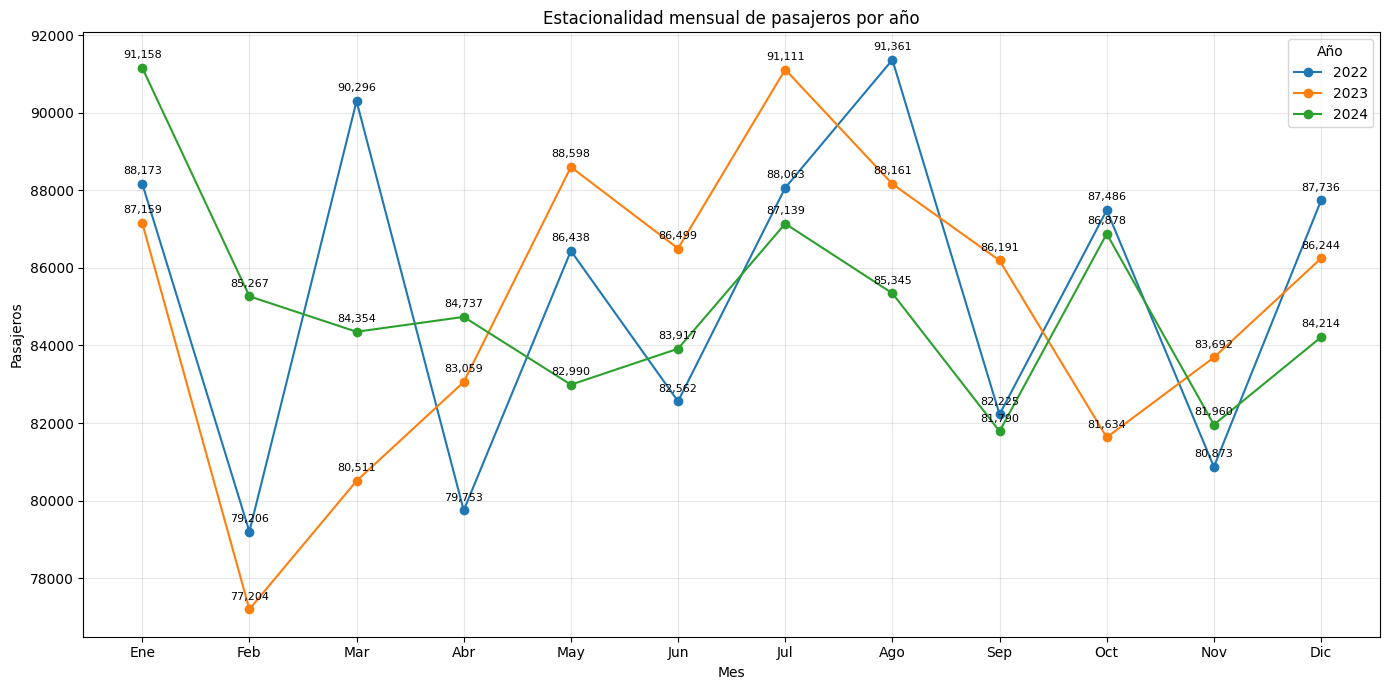

In [204]:
viajeros_mes = (
    fact_viajes_limpio
    .groupby(['anno', 'mes'])['pasajeros_subidos']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

# Una línea por cada año
for anno in sorted(viajeros_mes['anno'].unique()):

    datos_anno = viajeros_mes[
        viajeros_mes['anno'] == anno
    ]

    plt.plot(
        datos_anno['mes'],
        datos_anno['pasajeros_subidos'],
        marker='o',
        label=str(anno)
    )

    # Valor de cada punto
    for _, fila in datos_anno.iterrows():
        plt.annotate(
            f"{fila['pasajeros_subidos']:,.0f}",
            (fila['mes'], fila['pasajeros_subidos']),
            xytext=(0, 7),
            textcoords='offset points',
            ha='center',
            fontsize=8
        )

plt.title('Estacionalidad mensual de pasajeros por año')
plt.xlabel('Mes')
plt.ylabel('Pasajeros')

plt.xticks(
    range(1, 13),
    [
        'Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
        'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'
    ]
)

plt.legend(title='Año')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Visualización 2**

***Pregunta de negocio:** ¿Qué líneas soportan la mayor parte de la demanda?*

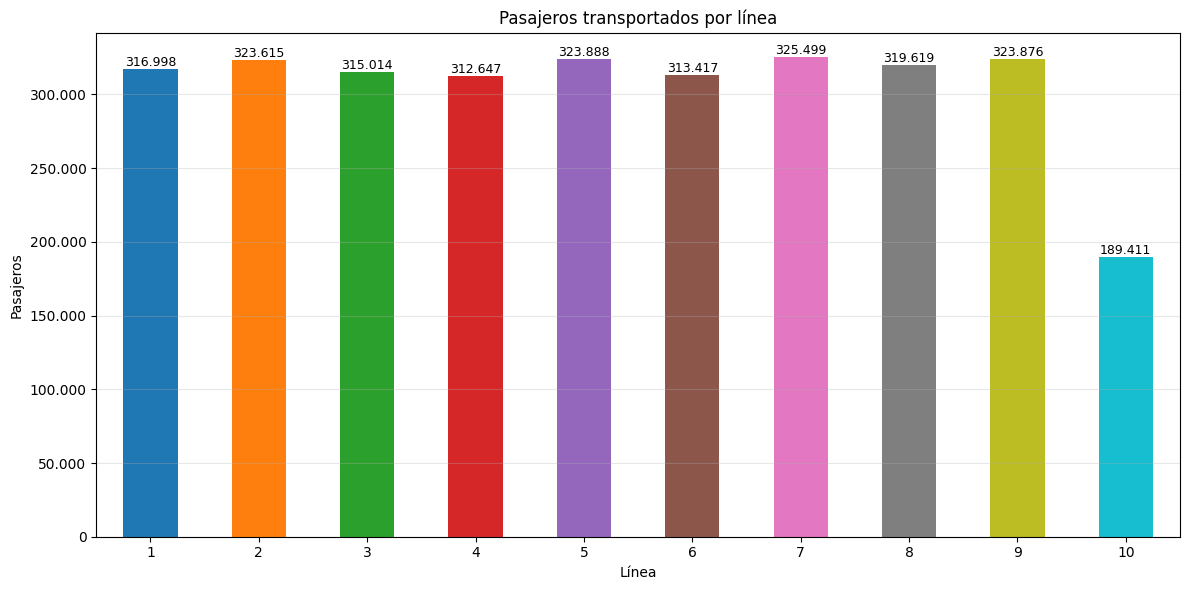

In [205]:
viajeros_linea = (
    fact_viajes_limpio
    .groupby('linea_id')['pasajeros_subidos']
    .sum()
    .sort_index()
)

plt.figure(figsize=(12, 6))

ax = viajeros_linea.plot(
    kind='bar',
    color=plt.cm.tab10(range(len(viajeros_linea)))
)

plt.title('Pasajeros transportados por línea')
plt.xlabel('Línea')
plt.ylabel('Pasajeros')

# Formato del eje Y con separador de miles
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

# Valores encima de cada barra
for i, valor in enumerate(viajeros_linea):
    ax.text(
        i,
        valor,
        f'{valor:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Visualización 3**

***Pregunta de negocio:** ¿Cuál es el retraso medio por línea?*

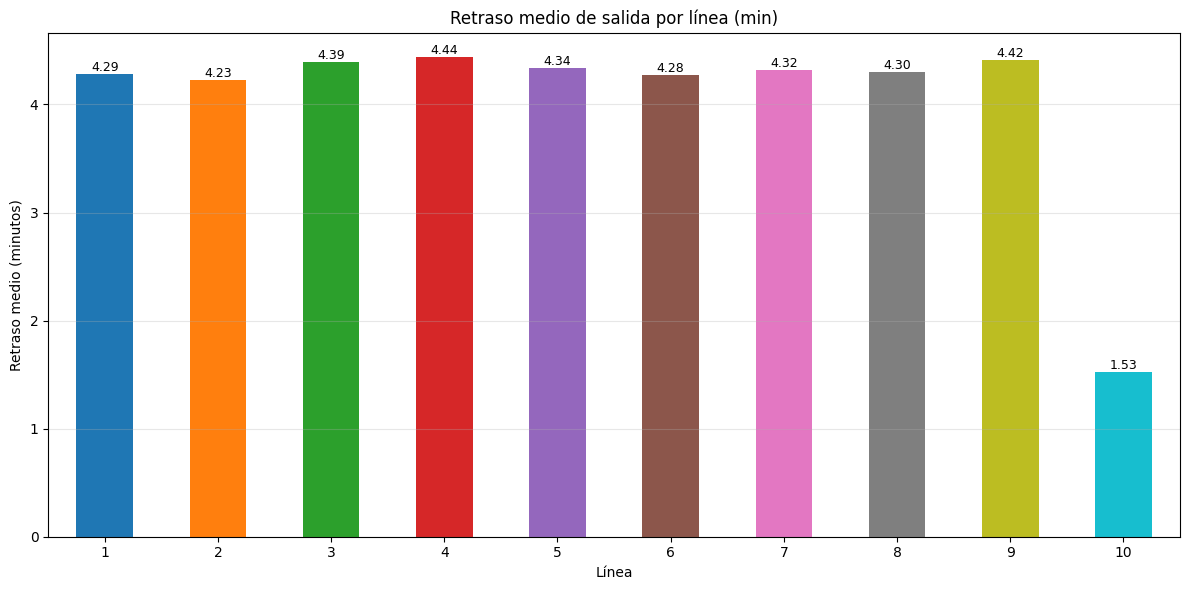

In [206]:
retraso_linea = (
    fact_viajes_limpio
    .groupby('linea_id')['retraso_salida_min']
    .mean()
    .sort_index()
)

plt.figure(figsize=(12, 6))

ax = retraso_linea.plot(
    kind='bar',
    color=plt.cm.tab10(range(len(retraso_linea)))
)

plt.title('Retraso medio de salida por línea (min)')
plt.xlabel('Línea')
plt.ylabel('Retraso medio (minutos)')

# Valores encima de cada barra
for i, valor in enumerate(retraso_linea):
    ax.text(
        i,
        valor,
        f'{valor:.2f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Visualización 4**

***Pregunta de negocio:** ¿Cómo se distribuyen las incidencias?*

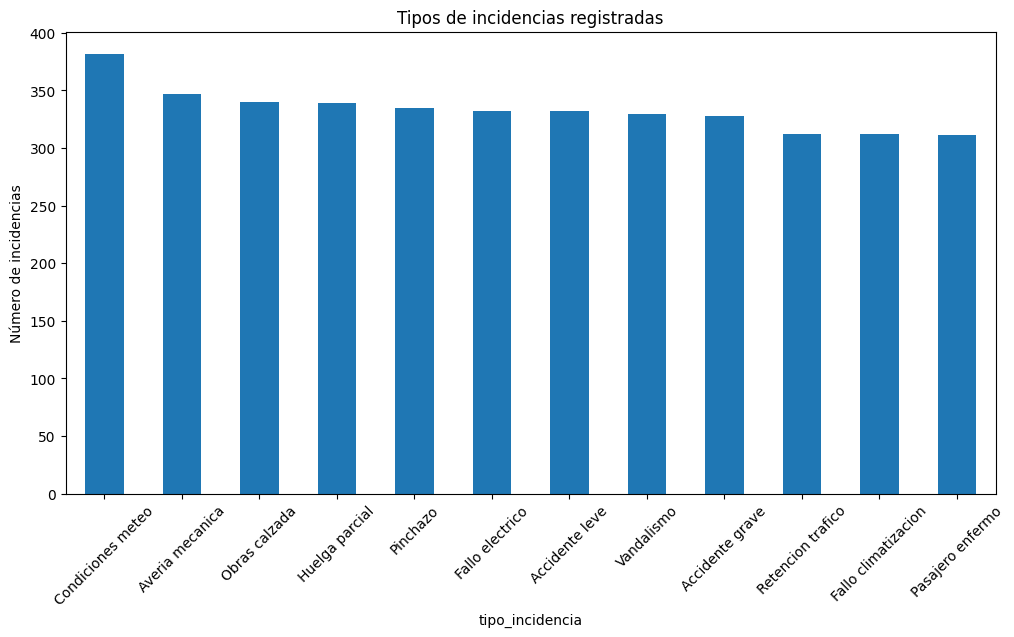

In [207]:
plt.figure(figsize=(12,6))

fact_incidencias_limpio['tipo_incidencia'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Tipos de incidencias registradas')
plt.ylabel('Número de incidencias')


plt.xticks(rotation=45)

plt.show()

**Visualización 5**

***Pregunta de negocio:** ¿Cómo se relacionan el coste medio y el número de intervenciones según el tipo de mantenimiento?*

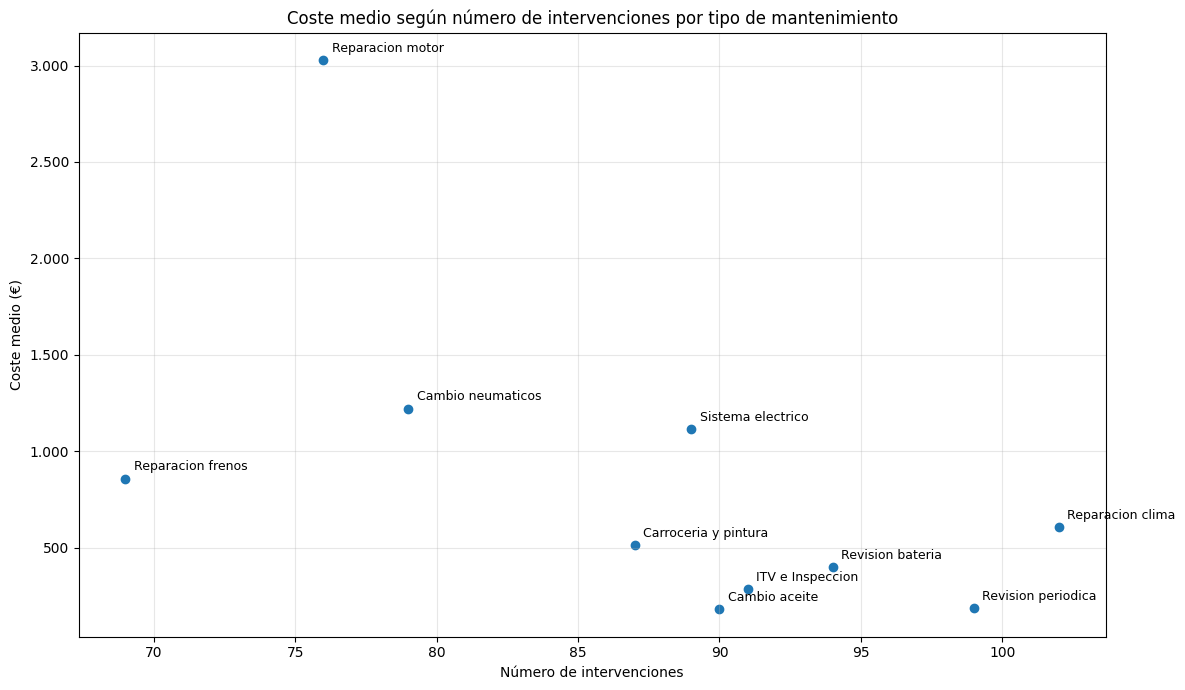

In [208]:
costes = (
    fact_mantenimiento_limpio
    .groupby('tipo_mantenimiento')
    .agg(
        coste_medio=('coste_eur', 'mean'),
        num_intervenciones=('coste_eur', 'count')
    )
    .reset_index()
)

plt.figure(figsize=(12, 7))

plt.scatter(
    costes['num_intervenciones'],
    costes['coste_medio']
)

# Etiquetas de cada punto
for _, fila in costes.iterrows():
    plt.annotate(
        fila['tipo_mantenimiento'],
        (
            fila['num_intervenciones'],
            fila['coste_medio']
        ),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9
    )

plt.title('Coste medio según número de intervenciones por tipo de mantenimiento')
plt.xlabel('Número de intervenciones')
plt.ylabel('Coste medio (€)')

# Formato del eje Y
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f'{x:,.0f}'.replace(',', '.')
    )
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Visualización 6**

***Pregunta de negocio:** ¿Existe relación entre la antigüedad y el kilometraje de los vehículos?*

In [209]:
# Creamos una copia del dataset para poder hacer la visualización sin modificar el dataset limpio original ya que calcularemos una columna nueva
dim_vehiculo_visual6 = dim_vehiculo_limpio.copy()

dim_vehiculo_visual6['antiguedad'] = (
    2025 - dim_vehiculo_visual6['anno_fabricacion']
)

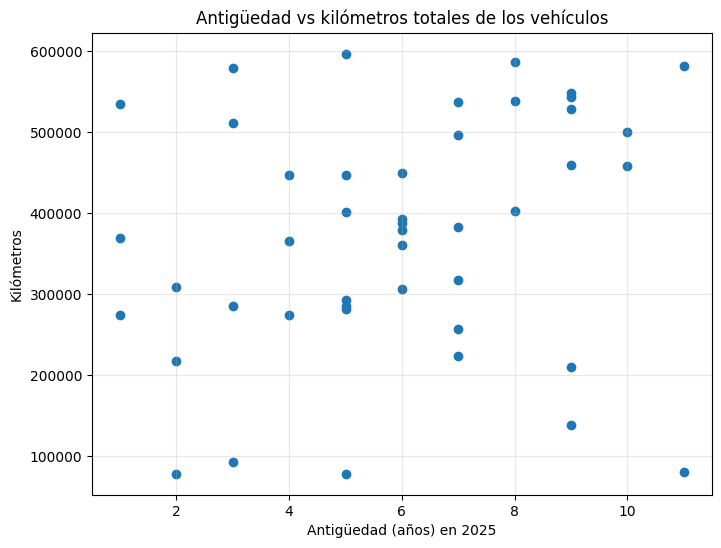

In [210]:
plt.figure(figsize=(8,6))

plt.scatter(
    dim_vehiculo_visual6['antiguedad'],
    dim_vehiculo_visual6['km_totales']
)

plt.xlabel('Antigüedad (años) en 2025')
plt.ylabel('Kilómetros')

plt.title('Antigüedad vs kilómetros totales de los vehículos')

plt.grid(alpha=0.3)

plt.show()

**Visualización 7**

***Pregunta de negocio:** ¿Las líneas que más incidencias sufren son también las que presentan mayores retrasos?*

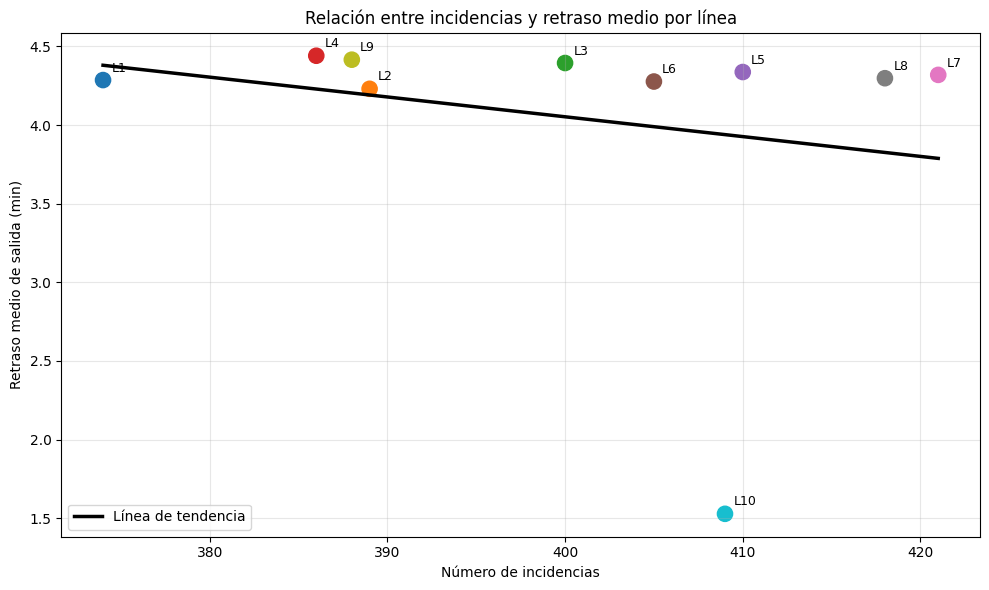

In [211]:
# Calcular número de incidencias por línea
incidencias_linea = (
    fact_incidencias_limpio
    .groupby('linea_id')
    .size()
    .reset_index(name='num_incidencias')
)

# Calcular retraso medio por línea
retrasos_linea = (
    fact_viajes_limpio
    .groupby('linea_id')['retraso_salida_min']
    .mean()
    .reset_index(name='retraso_medio')
)

# Unir ambas tablas
comparativa = incidencias_linea.merge(
    retrasos_linea,
    on='linea_id'
)

# Calcular línea de tendencia
coef = np.polyfit(
    comparativa['num_incidencias'],
    comparativa['retraso_medio'],
    1
)

x = np.linspace(
    comparativa['num_incidencias'].min(),
    comparativa['num_incidencias'].max(),
    100
)

y = coef[0] * x + coef[1]

# Gráfico
plt.figure(figsize=(10, 6))

# Un color diferente para cada punto
colores = plt.cm.tab10(range(len(comparativa)))

plt.scatter(
    comparativa['num_incidencias'],
    comparativa['retraso_medio'],
    s=120,
    c=colores
)

# Línea de relación
plt.plot(
    x,
    y,
    linewidth=2.5,
    color='black',
    label='Línea de tendencia'
)

# Etiquetas de cada línea
for _, fila in comparativa.iterrows():
    plt.annotate(
    f"L{int(fila['linea_id'])}",
    (
        fila['num_incidencias'],
        fila['retraso_medio']
    ),
    xytext=(6, 6),
    textcoords='offset points',
    fontsize=9
)

plt.title('Relación entre incidencias y retraso medio por línea')
plt.xlabel('Número de incidencias')
plt.ylabel('Retraso medio de salida (min)')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Visualización 8**

***Pregunta de negocio:** ¿Cuál es la relación entre el número medio de pasajeros y la franja horaria?*

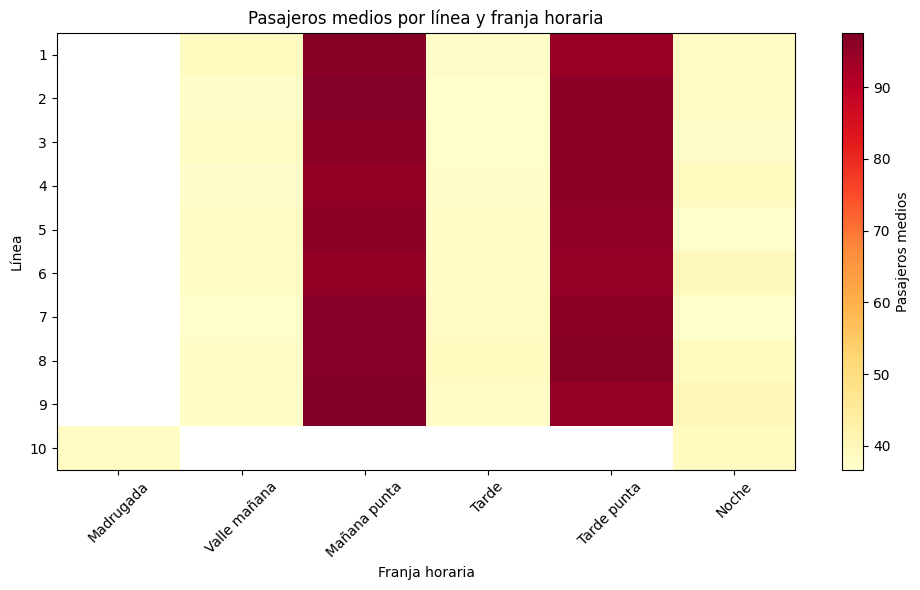

In [212]:
# Crear tabla dinámica
heatmap = fact_viajes_limpio.pivot_table(
    values='pasajeros_subidos',
    index='linea_id',
    columns='franja_horaria',
    aggfunc='mean'
)

# Orden lógico de las franjas
orden = [
    'Madrugada',
    'Valle mañana',
    'Mañana punta',
    'Tarde',
    'Tarde punta',
    'Noche'
]

# Mantener sólo las existentes
heatmap = heatmap[[c for c in orden if c in heatmap.columns]]

plt.figure(figsize=(10,6))

plt.imshow(
    heatmap,
    aspect='auto',
    cmap='YlOrRd'
)

plt.colorbar(label='Pasajeros medios')

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index
)

plt.title('Pasajeros medios por línea y franja horaria')
plt.xlabel('Franja horaria')
plt.ylabel('Línea')

plt.tight_layout()
plt.show()

## 07. Conclusiones

El análisis exploratorio (EDA) realizado sobre los datos de MetroBus ha permitido conocer la estructura, calidad y comportamiento general de las nueve tablas que forman el modelo de datos. El dataset está compuesto por tres tablas de hechos (fact_viajes, fact_incidencias y fact_mantenimiento) y seis tablas dimensionales relacionadas con líneas, vehículos, conductores, paradas, tarifas y cocheras.

Los datos presentan una estructura coherente y un nivel de calidad suficiente para realizar las siguientes fases del proyecto. Las tablas no contienen registros duplicados y la carga de los datos se ha realizado correctamente. Sin embargo, durante la exploración se han identificado distintos problemas de calidad que requieren tratamiento previo a la construcción del modelo analítico y del cuadro de mando:

**Valores Nulos:** La presencia de estos valores es reducida en todas las tablas, situándose como máximo en un 3,33 %, por lo que se ha optado por aplicar diferentes estrategias para reconstruir o imputar los valores en base a información disponible por otras variables. En cada apartado que hemos ido trabajando, se ha comentado la operativa, dejo aquí algunos ejemplos:

- En fact_viajes, pasajeros_subidos contiene únicamente 40 valores nulos (0,08 % de los registros). Debido al reducido número de valores ausentes (40, un 0,08 %), se revisó su posible relación con variables como línea, franja horaria, día de la semana y ocupación, pero finalmente se optó por imputarlos utilizando la mediana global, al ser más robusta frente a valores extremos.
- consumo presenta 1.065 valores ausentes (2,13 % de la tabla). Se investigó su posible relación con variables como el combustible, el vehículo, los kilómetros recorridos y la línea. Al no encontrar una relación suficientemente clara para realizar una imputación fiable, se optó por utilizar la mediana (5,34), al ser más robusta frente a valores extremos.
- En fact_mantenimiento, la variable categoria contiene 15 valores nulos (1,71 % del total). Al ser una variable relacionada con el tipo de mantenimiento, se reconstruye la información gracias a ésta.
- Hablando de las tablas dimensionales, los valores ausentes son muy puntuales. El combustible faltante de un vehículo se infiere a partir de su modelo; la antigüedad de los conductores se calcula a partir de su año de incorporación; y la información geográfica o de accesibilidad de una parada se completa mediante la información disponible en otras columnas y/o mediante fuentes externas (estadística).

El bajo porcentaje de valores ausentes ha permitido mantener todos los registros, evitando la pérdida de cualquier información, por irrelevante que parezca, al eliminar filas. Las imputaciones realizadas se han ido justificando y documentando una a una, para saber dónde se originan de cara a los análisis posteriores.

**Normalización de variables categóricas:** En las variables categóricas principalmente se han detectado inconsistencias de formato, que han sido corregidas para igualarlas y que no sean interpretadas como valores diferentes por tener diferentes capitalizaciones o formatos. Algunos ejemplos:

- dia_semana: Valores escritos en capitalización estándar y en mayúsculas.
- combustible: Mismo caso que en dia_semana.
- turno_habitual: Diferentes formatos para representar un mismo turno (Con o sin tramo horario).
- barrio: Mismo caso que los dos primeros

En todos los casos se ha mantenido el formato que aparece más a menudo como lo estándar, normalizando y unificando la representación de los valores, para evitar duplicidades artificiales en agrupaciones, filtros y visualizaciones posteriores.

**Tipos de datos y preparación temporal:** Las columnas relativas a fecha se habían importado como texto (object), se han transformado a Datetime para poder realizar análisis temporales, agrupar en periodos y calcular evoluciones relativas al servicio. Respecto a las horas, las hemos mantenido como objeto ya que el dataset contiene indicadores calculados que se podrían obtener al pasar las horas al formato adecuado (retraso, duración del viaje, etc...), así mantenemos el modelo lo más simplificado posible, centrándonos en las partes relevantes para el análisis. 

**Valores atípicos/outliers y sospechosos o anómalos:** El análisis de distribución estadística de los valores nos ha permitido identificar algunos que se alejan del comportamiento general, como -99 en el retraso de salida (podría tratars de un codigo  interno de la empresa) y 999 en la latitud de una parada. En el caso del retraso de salida se opta por reconstruir el retraso mediante la diferencia entre la hora de salida programada con la real, mientras que la latitud 999, al no representar una coordenada válida y no poder reconstruirse de forma fiable, se trató como un valor ausente y se imputó mediante la media de latitud de las paradas del mismo barrio. Por otro lado, los valores extremos de duración y coste en fact_incidencias se conservaron al considerarse compatibles con incidencias de mayor gravedad.

Para todos los valores extremos se ha optado por interpretarlos dentro de su contexto operacional, no eliminándolos automáticamente para no perder contexto/información relevante.

**Principales hallazgos operativos:** En relación a lo anterior, las visualizaciones gráficas también nos han permitido identificar patrones relevantes en el funcionamiento de MetroBus. Por ejemplo, la evolución mes a mes del número de pasajeros varía a lo largo del periodo analizado, sin una tendencia sostenida. La demanda se mantiene relativamente estable, con algunos periodos que presentan picos o descensos puntuales. Esto podría deberse a la estacionalidad, periodos festivos, actividad laboral o las características específicas de cada línea.

Los pasajeros transportados por línea se distribuyen de manera más o menos equilibrada entre las líneas, salvo la línea 10, que presenta un volumen notablemente inferior al resto. Esta diferencia también se observa en los retrasos medios de salida, esto se debe a que es la única línea nocturna.

Si analizamos de manera conjunta las incidencias y los retrasos por línea, observamos que no existe una relación clara entre ambas variables, ya que no todas las líneas con mayor número de incidencias son las que presentan mayores retrasos. Por tanto, se debería valorar la relación de las incidencias con su gravedad, duración y tipo.

En fact_mantenimiento, los valores negativos de coste se analizaron individualmente y se comprobó que no existían evidencias suficientes para considerarlos devoluciones o abonos. Tras contrastarlo con la empresa, se interpretaron como errores de introducción y se transformaron a su valor absoluto. En dim_vehiculo, el valor -500 de km_totales tampoco pudo reconstruirse de forma fiable mediante el histórico de mantenimientos, debido a las inconsistencias detectadas en km_en_revision. Tras contrastarlo con la empresa, se estableció el valor en 500.000 km, manteniendo la base del dato original pero corrigiendo su signo y magnitud para hacerlo coherente.

Hablando del mantenimiento, hay una diferencia considerable por tipo de intervención. Las de motor presentan un coste medio elevado, por lo que constituyen un tipo de mantenimiento especialmente relevante desde el punto de vista económico, podemos profundizar posteriormente la relación entre costes, antigüedad de los vehículos, kilometraje y tipo de combustible ya que la gráfica representa el coste medio.

**Hipótesis generadas:** En base a todo lo que acabamos de comentar, podemos plantear diferentes hipótesis para analizar con más profundidad en las siguientes fases:

- La demanda de pasajeros podría estar condicionada por una combinación de línea, franja horaria y día de la semana (si es laboral o festivo).
- La línea 10 tiene un comportamiento diferente al resto de la red en diversos factores, por lo que deberíamos estudiar si se debe a sus características operativas o al papel que cumple dentro del sistema.
- El número de incidencias no tiene una relación directa con el retraso medio de las líneas. La severidad y el tipo de incidencia parecen influir más que la frecuencia de estas.
- Las intervenciones de motor presentan un coste medio elevado, por lo que podrían representar un tipo de mantenimiento especialmente relevante desde el punto de vista económico.
- El consumo de los vehículos podría depender además del combustible, el modelo, los kilómetros recorridos y las características de las rutas.
- La antigüedad y el kilometraje podrían influir en la frecuencia, coste y número de operaciones de mantenimiento.

El EDA realizado hasta ahora confirma que el dataset contiene información suficiente para estudiar cómo funciona MetroBus desde diferentes puntos de vista: demanda de pasajeros, puntualidad, incidencias, mantenimiento, flota y recursos operativos.

Los problemas detectados son puntuales y tratables. No existen registros duplicados y el bajo porcentaje de valores nulos, junto con la coherencia de las relaciones entre las tablas, permite continuar el proceso sin haber tenido que realizar una depuración especialmente intensa.

Algunas métricas deben interpretarse de forma conjunta. Como hemos visto, no existe una relación clara entre incidencias y retrasos por línea, y un valor extremo no implica necesariamente que sea erróneo. Por ello, debemos prestar atención a la contextualización de los datos para construir el modelo analítico y el cuadro de mando.

El siguiente paso será completar las transformaciones definitivas, crear la base de datos y preparar su carga para la explotación final en Power BI.

## 08. Extra - Revisión antes de fase 2 (SQL)

Antes de empezar el documento propiamente dicho para la creación de la BBDD, ejecutamos una impresión de los datasets como tablas para obtener lo que serían el nombre y tipo de cada columna

In [213]:
tablas = {
    'fact_viajes': fact_viajes,
    'fact_incidencias': fact_incidencias,
    'fact_mantenimiento': fact_mantenimiento,
    'dim_linea': dim_linea,
    'dim_vehiculo': dim_vehiculo,
    'dim_conductor': dim_conductor,
    'dim_parada': dim_parada,
    'dim_tarifa': dim_tarifa,
    'dim_depot': dim_depot
}

for nombre, df in tablas.items():
    print(f"\n{'='*50}")
    print(nombre)
    print(f"{'='*50}")
    print(list(df.columns))


fact_viajes
['viaje_id', 'linea_id', 'vehiculo_id', 'conductor_id', 'parada_origen_id', 'parada_destino_id', 'fecha', 'anno', 'mes', 'dia_semana', 'es_festivo', 'franja_horaria', 'hora_salida_prog', 'hora_salida_real', 'hora_llegada_real', 'retraso_salida_min', 'duracion_real_min', 'pasajeros_subidos', 'ocupacion_pct', 'km_programados', 'km_recorridos', 'viaje_completado', 'consumo', 'tarifa_predominante_id']

fact_incidencias
['incidencia_id', 'viaje_id', 'vehiculo_id', 'conductor_id', 'linea_id', 'fecha', 'anno', 'mes', 'hora_incidencia', 'tipo_incidencia', 'categoria', 'severidad', 'requiere_retirada', 'duracion_resolucion_min', 'vehiculo_sustituto', 'coste_estimado_eur']

fact_mantenimiento
['mantenimiento_id', 'vehiculo_id', 'depot_id', 'fecha_entrada', 'fecha_salida', 'anno', 'mes', 'tipo_mantenimiento', 'categoria', 'es_correctivo', 'dias_fuera_servicio', 'km_en_revision', 'coste_eur', 'proveedor', 'garantia_meses']

dim_linea
['linea_id', 'codigo', 'nombre', 'tipo', 'km_recorr

In [214]:
for nombre, df in {
    'fact_viajes': fact_viajes_limpio,
    'fact_incidencias': fact_incidencias_limpio,
    'fact_mantenimiento': fact_mantenimiento_limpio,
    'dim_linea': dim_linea_limpio,
    'dim_vehiculo': dim_vehiculo_limpio,
    'dim_conductor': dim_conductor_limpio,
    'dim_parada': dim_parada_limpio,
    'dim_tarifa': dim_tarifa_limpio,
    'dim_depot': dim_depot_limpio
}.items():

    print(f"\n{'='*50}")
    print(nombre)
    print(f"{'='*50}")
    print(df.dtypes)


fact_viajes
viaje_id                           int64
linea_id                           int64
vehiculo_id                        int64
conductor_id                       int64
parada_origen_id                   int64
parada_destino_id                  int64
fecha                     datetime64[ns]
anno                               int64
mes                                int64
dia_semana                        object
es_festivo                          bool
franja_horaria                    object
hora_salida_prog                  object
hora_salida_real                  object
hora_llegada_real                 object
retraso_salida_min                 int64
duracion_real_min                  int64
pasajeros_subidos                  int64
ocupacion_pct                    float64
km_programados                   float64
km_recorridos                    float64
viaje_completado                    bool
consumo                          float64
tarifa_predominante_id             int64
dty

## 09. Extra (II) - Guardado CSVs limpios

Exportamos los dataframes finales a CSV y los preparamos para la Fase 2.

In [215]:
import os

# Crear carpeta de salida en el repositorio
os.makedirs("data_limpios", exist_ok=True)

# Diccionario con las tablas limpias
tablas_limpias = {
    "dim_depot": dim_depot_limpio,
    "dim_linea": dim_linea_limpio,
    "dim_vehiculo": dim_vehiculo_limpio,
    "dim_conductor": dim_conductor_limpio,
    "dim_parada": dim_parada_limpio,
    "dim_tarifa": dim_tarifa_limpio,
    "fact_viajes": fact_viajes_limpio,
    "fact_incidencias": fact_incidencias_limpio,
    "fact_mantenimiento": fact_mantenimiento_limpio
}

# Exportar cada DataFrame
for nombre, df in tablas_limpias.items():
    ruta = f"data_limpios/{nombre}.csv"
    df.to_csv(ruta, index=False, encoding="utf-8")
    print(f"{nombre}: {len(df):,} registros → {ruta}")

dim_depot: 3 registros → data_limpios/dim_depot.csv
dim_linea: 10 registros → data_limpios/dim_linea.csv
dim_vehiculo: 45 registros → data_limpios/dim_vehiculo.csv
dim_conductor: 30 registros → data_limpios/dim_conductor.csv
dim_parada: 120 registros → data_limpios/dim_parada.csv
dim_tarifa: 9 registros → data_limpios/dim_tarifa.csv
fact_viajes: 50,000 registros → data_limpios/fact_viajes.csv
fact_incidencias: 4,000 registros → data_limpios/fact_incidencias.csv
fact_mantenimiento: 876 registros → data_limpios/fact_mantenimiento.csv


In [216]:
# Verificación final CSVs

print("\n--- Verificación final ---")

for nombre, df in tablas_limpias.items():
    print(
        f"{nombre:25} | "
        f"filas: {len(df):>6,} | "
        f"columnas: {len(df.columns):>2} | "
        f"nulos: {df.isna().sum().sum():>3}"
    )


--- Verificación final ---
dim_depot                 | filas:      3 | columnas:  6 | nulos:   0
dim_linea                 | filas:     10 | columnas:  7 | nulos:   0
dim_vehiculo              | filas:     45 | columnas: 12 | nulos:   0
dim_conductor             | filas:     30 | columnas: 10 | nulos:   0
dim_parada                | filas:    120 | columnas: 10 | nulos:   0
dim_tarifa                | filas:      9 | columnas:  6 | nulos:   0
fact_viajes               | filas: 50,000 | columnas: 24 | nulos:   0
fact_incidencias          | filas:  4,000 | columnas: 16 | nulos:   0
fact_mantenimiento        | filas:    876 | columnas: 15 | nulos:   0
